In [4]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import astropy

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools
from matplotlib import rcParams
import scienceplots
import pickle

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

import os
import xarray as xr
from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from explor.model import HotSpotPhaseCurveModel

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from matplotlib.lines import Line2D

from taurex.binning import FluxBinner
from binning_funcs import *
from scipy.optimize import curve_fit, brentq

In [5]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_fullnames = ["HD3167b","K2-141b","LHS1478b","TOI-431b","TOI-500b","TOI-561b","TOI-1416b","TOI-1807b"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_transit = [n * 3600 for n in planet_transit] #hours to seconds
T_transit_hours = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data

star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

In [3]:
planet_names = ["HD3167","K2141","lhs1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]

m_min = [4.44, 4.63, 2.31, 2.72, 1.24,  1.79, 3.01, 1.87]
m_max = [5.01, 5.32, 2.35, 3.42, 1.60,  2.25, 3.95, 3.04]

r_min = [1.569, 1.46, 1.193, 1.24, 1.04, 1.37, 1.54, 1.43]
r_max = [1.71, 1.56, 1.293, 1.32, 1.28, 1.424, 1.70, 1.587]

star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3]
star_age = np.array(star_age)*1e9

star_age_min = np.array([7.8,1.6,1.9,4.5,4.8,7.5,6.8,0.22])*1e9
star_age_max = np.array([13,12.5,8.3,5.7,5.2,13.8,7.0,0.38])*1e9

def average(arr_max, arr_min):
    arr = np.zeros(len(arr_max))
    for i in range(len(arr_max)):
        arr[i] = (arr_max[i] + arr_min[i]) / 2
    return arr

def bulk_density(m,r):
    return (3/4) * (1/np.pi) * (m / r**3)

m_avg = average(m_max, m_min)
r_avg = average(r_max, r_min)

bulk_density_avg = bulk_density(m_avg, r_avg)
bulk_density_max = bulk_density(np.array(m_max), np.array(r_min))
bulk_density_min = bulk_density(np.array(m_min), np.array(r_max))

#convert to g/cm^3
bulk_density_avg = bulk_density_avg * 23.04
bulk_density_max = bulk_density_max * 23.04
bulk_density_min = bulk_density_min * 23.04

In [4]:
rcParams['xtick.direction'] = 'in'         # ticks pointing inward (standard in astronomy)
rcParams['ytick.direction'] = 'in'
rcParams['xtick.top'] = True               # mirror ticks on top
rcParams['ytick.right'] = True
rcParams['xtick.major.size'] = 5
rcParams['xtick.minor.size'] = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True

rcParams['axes.linewidth'] = 2
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.8
rcParams['grid.linestyle'] = '-'

rcParams['font.family'] = 'serif'          # or 'sans-serif' (Nature/AAS style)
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 16
rcParams['axes.labelsize'] = 22            # axis label size
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['text.usetex'] = True             # render labels with LaTeX

## Scatter Plots

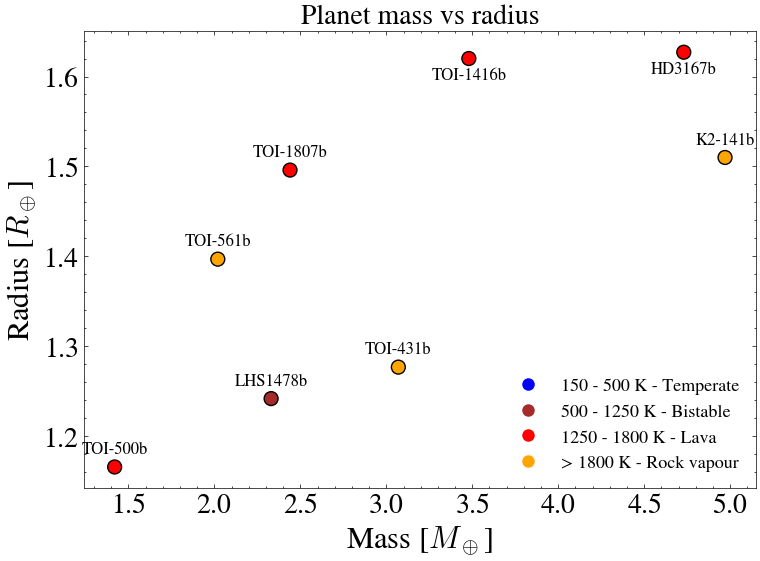

In [8]:
plt.style.use(['science', 'no-latex'])

#set color based on equilibrium temperature
planet_equilibrium_temperature = [1500, 2000, 750, 2000, 1500, 2000, 1500, 1500] #K, to be fixed according to archive data

if len(planet_equilibrium_temperature) == len(planet_names):
    colors = []
    for T in planet_equilibrium_temperature:
        if T < 500:
            colors.append('blue')
        elif 500 <= T < 1250:
            colors.append('brown')
        elif 1250 <= T < 1800:
            colors.append('red')
        else:
            colors.append('orange')

# scatter plot of planet mass vs radius
fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)

frame.scatter(planet_masses, planet_radius, color=colors, s=100, edgecolor='black')

for i, name in enumerate(planet_names):
    if name != "TOI1416" and name != "HD3167":
        frame.annotate(planet_fullnames[i], (planet_masses[i], planet_radius[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)
    else:
        #annotate them but below the point instead of above it
        frame.annotate(planet_fullnames[i], (planet_masses[i], planet_radius[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=12)
#create label for colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='150 - 500 K - Temperate', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='500 - 1250 K - Bistable', markerfacecolor='brown', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='1250 - 1800 K - Lava', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='> 1800 K - Rock vapour', markerfacecolor='orange', markersize=10)]


frame.set_title('Planet mass vs radius',fontsize=20)
frame.set_xlabel(r'Mass [$M_\oplus$]')
frame.set_ylabel(r'Radius [$R_\oplus$]')

frame.tick_params(axis='both', which='major')

frame.grid()
frame.legend(handles=legend_elements, loc='lower right', fontsize=13)
#tight layout
plt.tight_layout()
savefig('thesis-plots/planet_mass_radius_scatter.pdf', bbox_inches='tight')
show()

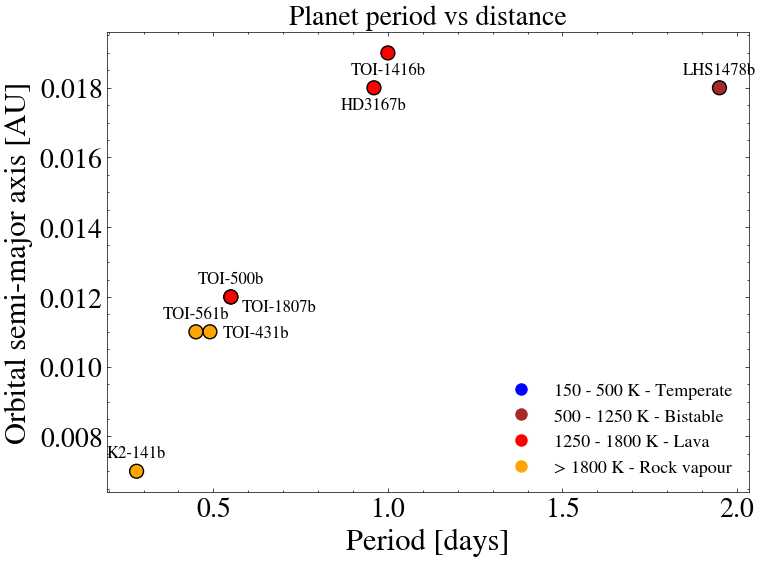

In [10]:
# scatter plot of planet mass vs radius

fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)

frame.scatter(planet_period, planet_distances, color=colors, s=100, edgecolor='black')

for i, name in enumerate(planet_names):
    if name != "TOI1416" and name != "HD3167" and name != "LHS1478" and name != "TOI431" and name != "TOI1807":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)
    elif name == "LHS1478":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(-7,10), ha='center', fontsize=12)
    elif name == "TOI431":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(33,-4), ha='center', fontsize=12)
    elif name == "TOI1807":
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(35,-10), ha='center', fontsize=12)
    else:
        #annotate them but below the point instead of above it
        frame.annotate(planet_fullnames[i], (planet_period[i], planet_distances[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=12)

#create label for colors
legend_elements = [Line2D([0], [0], marker='o', color='w', label='150 - 500 K - Temperate', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='500 - 1250 K - Bistable', markerfacecolor='brown', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='1250 - 1800 K - Lava', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='> 1800 K - Rock vapour', markerfacecolor='orange', markersize=10)]


frame.set_title('Planet period vs distance',fontsize=20)
frame.set_xlabel(r'Period [days]')
frame.set_ylabel(r'Orbital semi-major axis [AU]')

frame.tick_params(axis='both', which='major')

frame.grid()
frame.legend(handles=legend_elements, loc='lower right', fontsize=13)
#tight layout
plt.tight_layout()
savefig('thesis-plots/planet_period_distance_scatter.pdf', bbox_inches='tight')
show()

# Validation plots

In [11]:
#for all planets except toi-431, lhs1478 and k2141

with open('bulk_density_evolution.pkl', 'rb') as f:
    data_all = pickle.load(f)

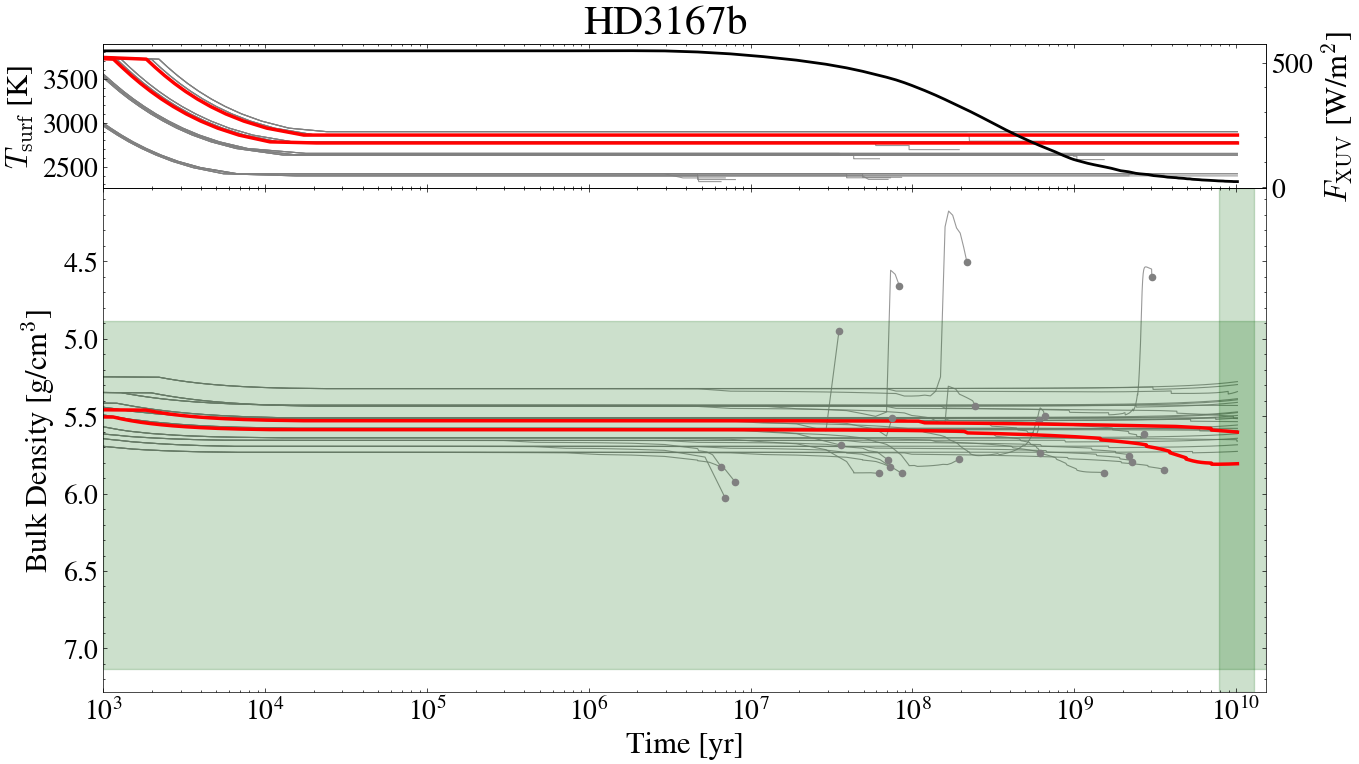

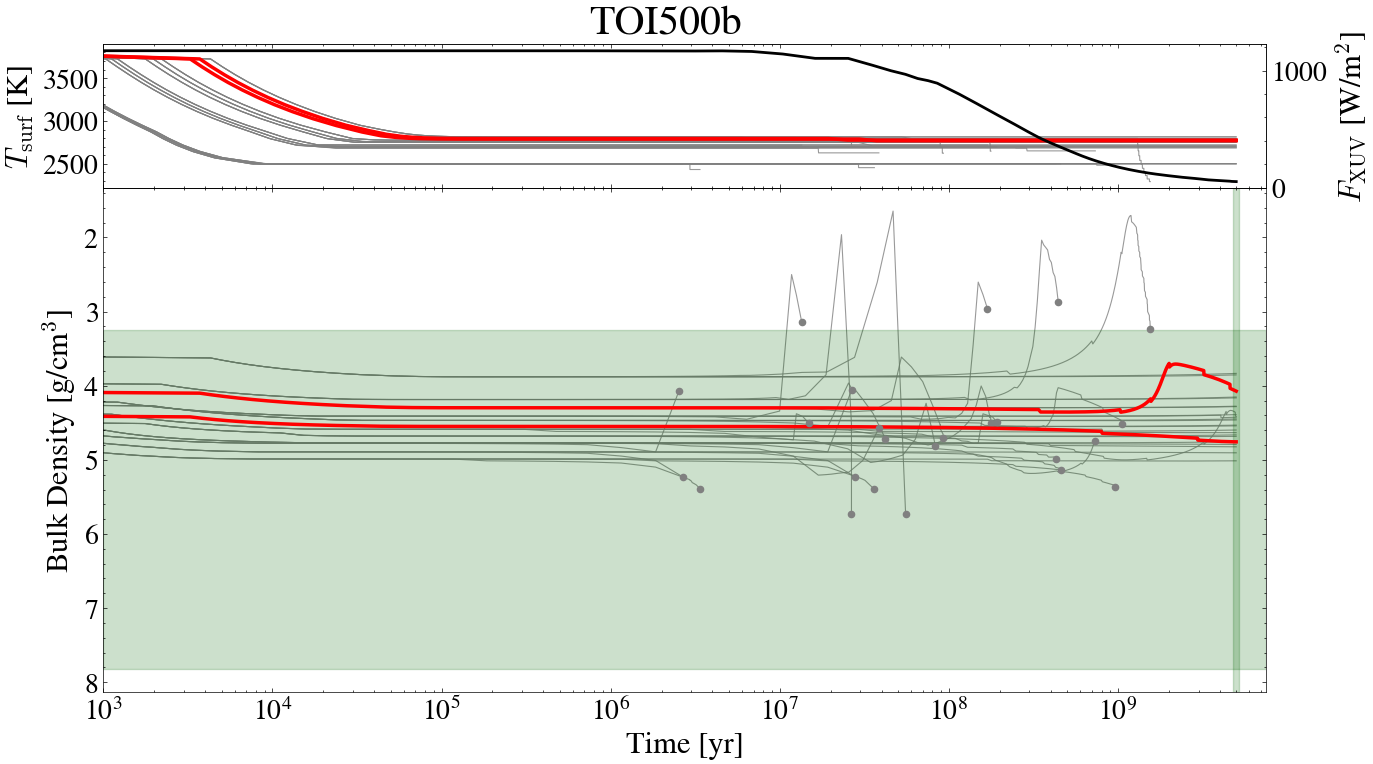

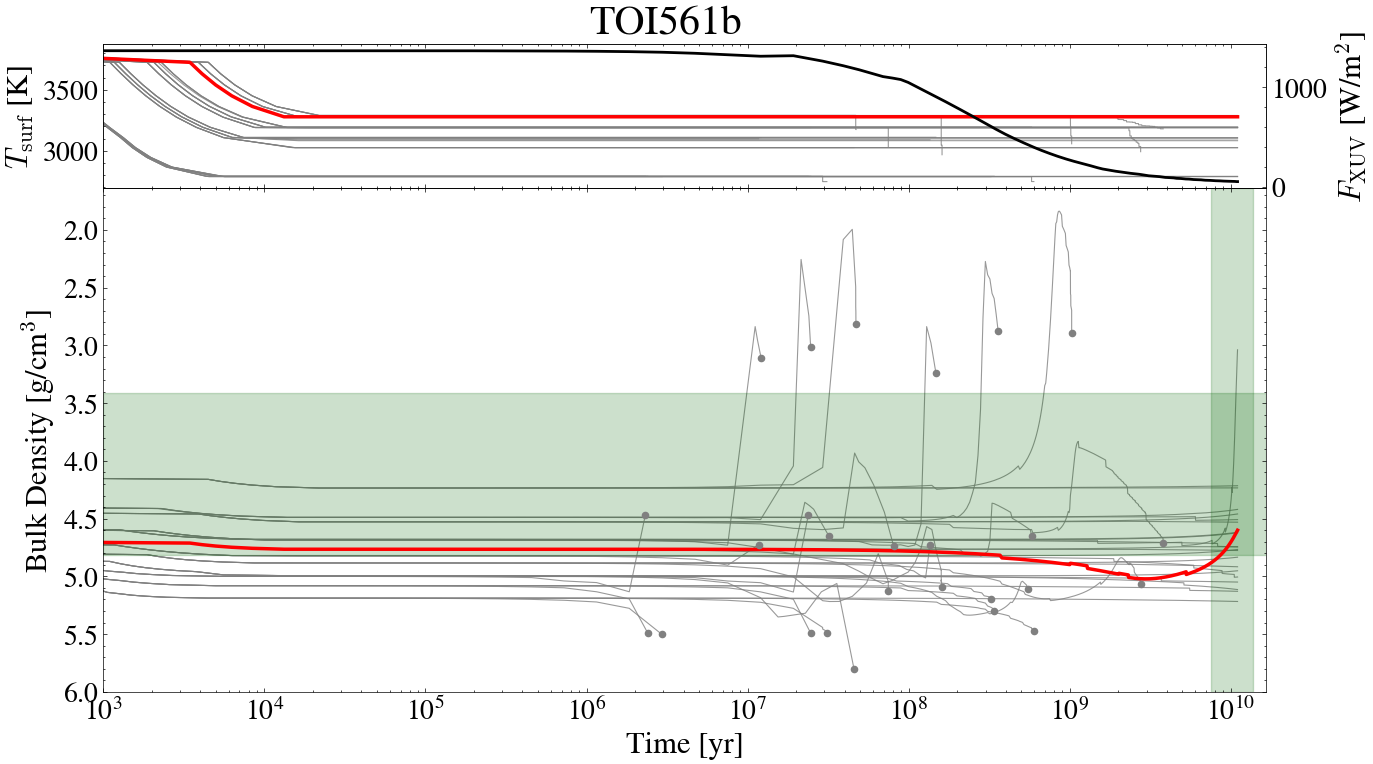

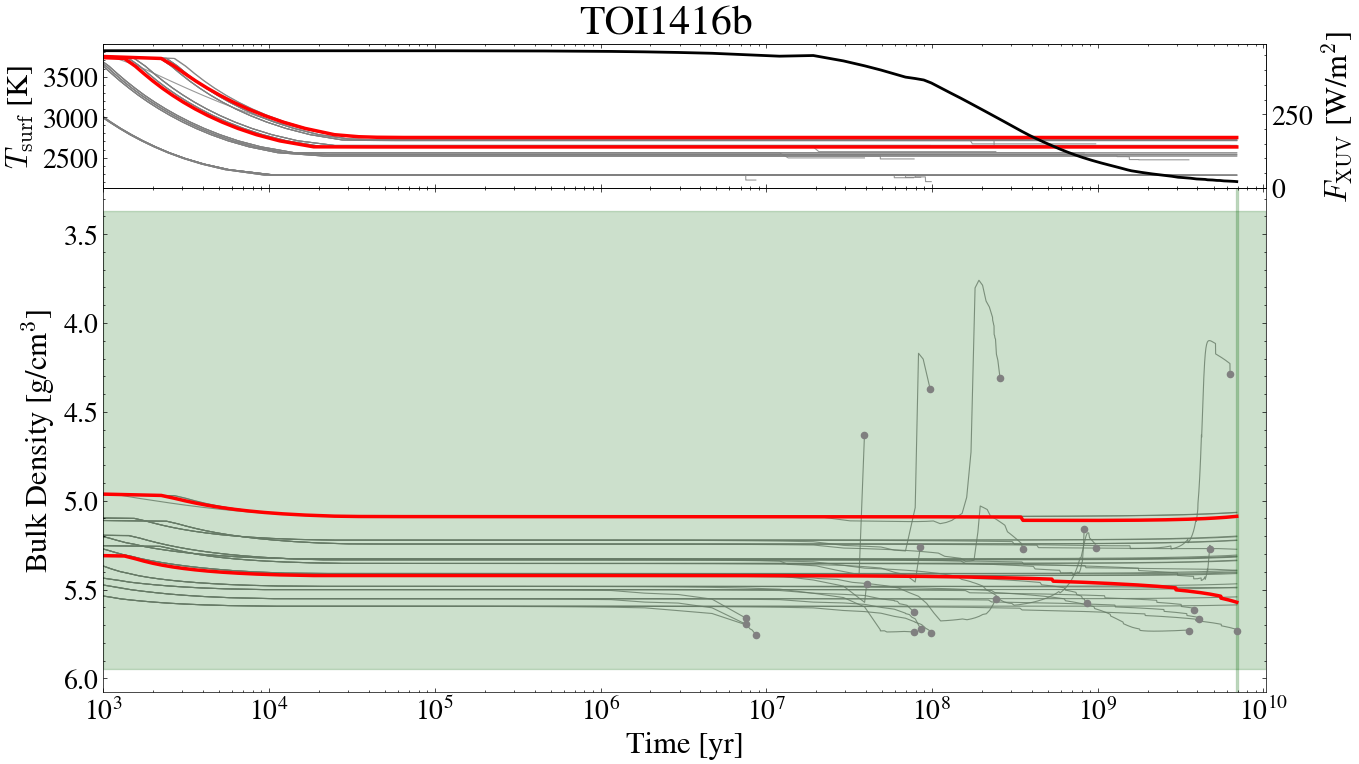

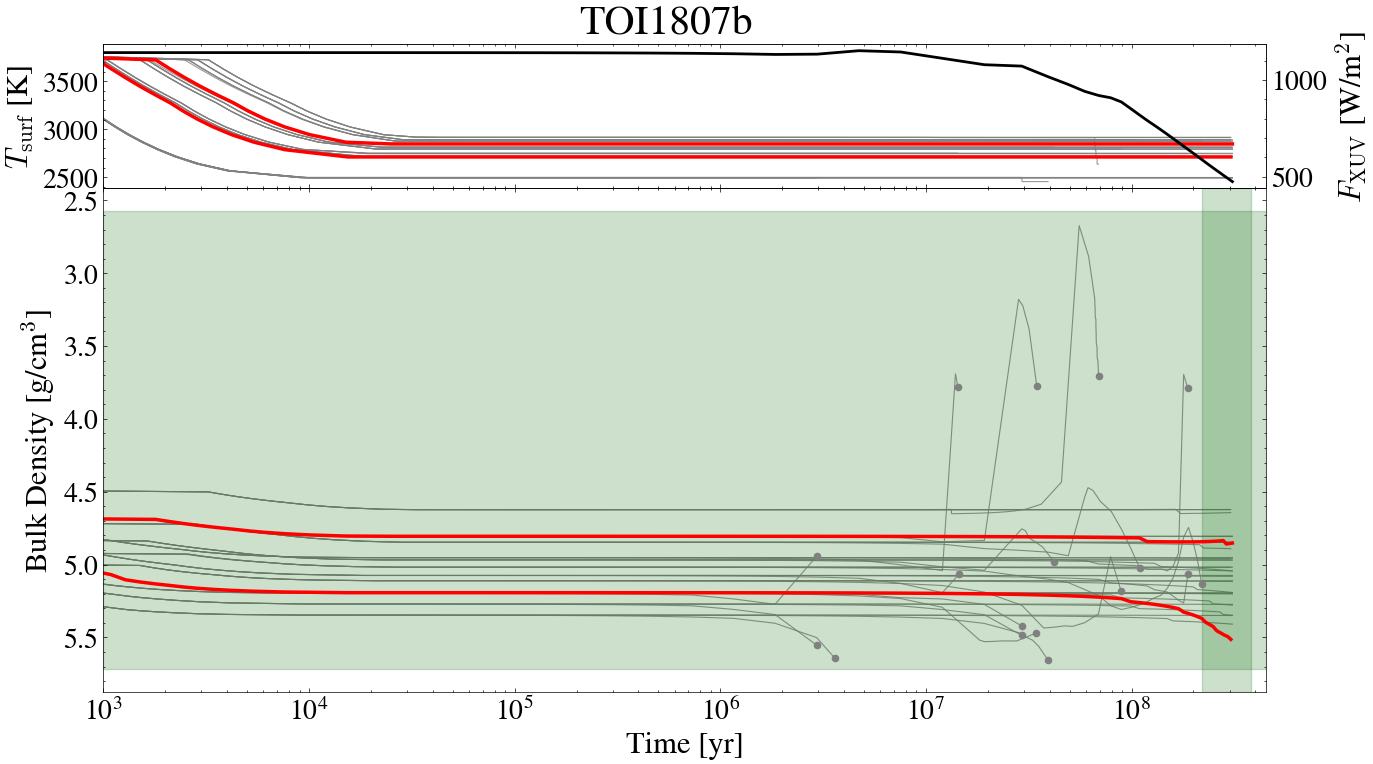

In [9]:
# Okabe-Ito colorblind-friendly palette for H_oceans
colors = {
    1.0:  '#0072B2',  # blue
    5.0:  '#009E73',  # green
    10.0: '#E69F00',  # orange
    20.0: '#D55E00',  # vermillion
    30.0: '#CC79A7',  # pink
}

h_ocean_values = [1.0, 5.0, 10.0, 20.0]
cmap = ListedColormap([colors[h] for h in h_ocean_values])
bounds = [0, 2, 8, 12, 28]
norm = BoundaryNorm(bounds, cmap.N)

# Cases to highlight per planet — all others will be gray
# Use planet names as keys, value is a list of case strings
highlighted_cases = {
    "HD3167":  ["case_000034", "case_000046"],
    "TOI500":  ["case_000042", "case_000046"],
    "TOI561":  ["case_000046"],
    "TOI1416": ["case_000034", "case_000038"],
    "TOI1807": ["case_000022", "case_000026"],
}

for planet, simulations in data_all.items():
    fig = figure(figsize=(15, 8))
    fig.suptitle(rf"{planet}b",fontsize=30, y=0.98)

    frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
    ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)


    ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
    ax_temp.set_xscale('log')
    ax_temp.tick_params(labelbottom=False)

    age      = star_age[planet_names.index(f"{planet}")]
    age_min  = star_age_min[planet_names.index(f"{planet}")]
    age_max  = star_age_max[planet_names.index(f"{planet}")]
    bd       = bulk_density_avg[planet_names.index(f"{planet}")]
    bd_min   = bulk_density_min[planet_names.index(f"{planet}")]
    bd_max   = bulk_density_max[planet_names.index(f"{planet}")]

    longest_sim = None
    max_time = -np.inf
    highlight = highlighted_cases.get(planet, [])

    for sim in simulations:
        is_highlighted = sim["case"] in highlight
        color   = 'red' if is_highlighted else 'gray'
        lw      = 2.5 if is_highlighted else 0.8
        zorder  = 2 if is_highlighted else 1

        frame.plot(sim["x"], sim["y"]/1000,
                   color=color, linestyle='solid', alpha=1.0 if is_highlighted else 0.8, linewidth=lw, zorder=zorder)
        if sim["x"][-1] < age:
            frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
        ax_temp.plot(sim["x"], sim["t_surf"],
                     color=color, linestyle='solid', alpha=1.0 if is_highlighted else 0.8, linewidth=lw, zorder=zorder)
        ax_temp.grid(False)

        if sim["x"][-1] > max_time:
            max_time = sim["x"][-1]
            longest_sim = sim

    if longest_sim is not None:
        ax2 = ax_temp.twinx()
        ax2.grid(False)
        ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
        ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
        ax2.tick_params(axis='both', which='major')

    #frame.errorbar(age, bd,
    #               xerr=([abs(age_min-age)], [abs(age_max-age)]),
    #               yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
    #               fmt='o', color='black', ecolor='black', elinewidth=3, capsize=5, zorder=5)
    
    #instead of error bars, create shaded regions for age and bulk density uncertainties
    frame.axvspan(age_min, age_max, color='darkgreen', alpha=0.2, zorder=1)
    frame.axhspan(bd_min, bd_max, color='darkgreen', alpha=0.2, zorder=1)

    #frame.scatter(age, bd, color='red', zorder=6)

    frame.set_xlabel('Time [yr]')
    frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
    frame.set_xscale('log')
    frame.tick_params(axis='both', which='major')
    frame.invert_yaxis()
    frame.set_xlim(1e3, age*1.5)
    #turn off grid
    frame.grid(False)
    if planet != "TOI431" and planet != "lhs1478" and planet != "K2141":
        savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
        show()
    plt.close()


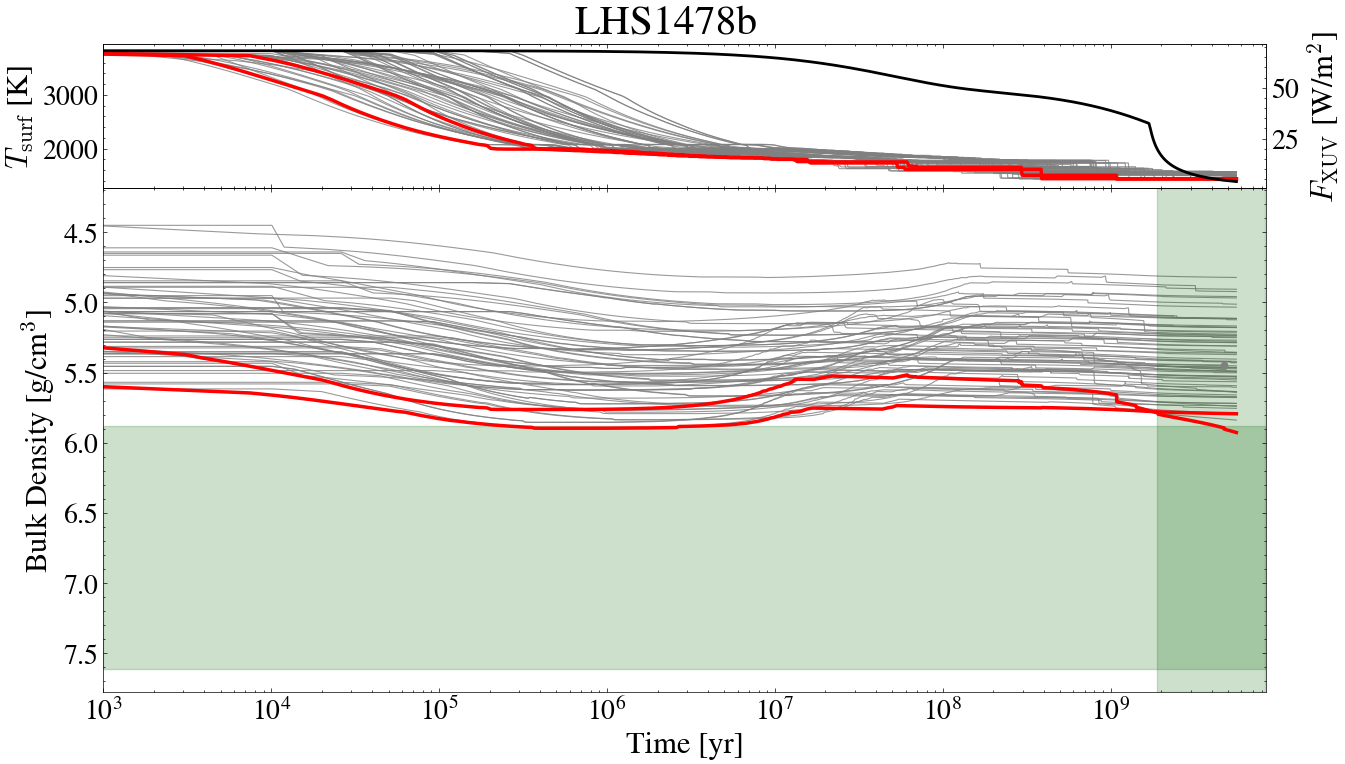

In [10]:
# plot for LHS1478 using bulk_density_evolution_LHS.pkl
with open('bulk_density_evolution_LHS.pkl', 'rb') as f:
    data_lhs = pickle.load(f)

highlighted_cases_lhs = ["case_000001", "case_000011"]

planet = "lhs1478"
simulations = data_lhs[planet]

fig = figure(figsize=(15, 8))
fig.suptitle(rf"LHS1478b", fontsize=30, y=0.98)

frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)


ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
ax_temp.set_xscale('log')
ax_temp.tick_params(labelbottom=False)

age      = star_age[planet_names.index(planet)]
age_min  = star_age_min[planet_names.index(planet)]
age_max  = star_age_max[planet_names.index(planet)]
bd       = bulk_density_avg[planet_names.index(planet)]
bd_min   = bulk_density_min[planet_names.index(planet)]
bd_max   = bulk_density_max[planet_names.index(planet)]

longest_sim = None
max_time = -np.inf

for sim in simulations:
    is_highlighted = sim["case"] in highlighted_cases_lhs
    color   = 'red' if is_highlighted else 'gray'
    lw      = 2.5 if is_highlighted else 0.8
    zorder  = 2 if is_highlighted else 1
    alpha   = 1.0 if is_highlighted else 0.8

    frame.plot(sim["x"], sim["y"]/1000,
               color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
    if sim["x"][-1] < age:
        frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
    ax_temp.plot(sim["x"], sim["t_surf"],
                 color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
    ax_temp.grid(False)

    if sim["x"][-1] > max_time:
        max_time = sim["x"][-1]
        longest_sim = sim

if longest_sim is not None:
    ax2 = ax_temp.twinx()
    ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
    ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
    ax2.tick_params(axis='both', which='major')
    ax2.grid(False)

#frame.errorbar(age, bd,
#               xerr=([abs(age_min-age)], [abs(age_max-age)]),
#               yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
#               fmt='o', color='black', ecolor='black', elinewidth=3, capsize=5, zorder=5)
#frame.scatter(age, bd, color='red', zorder=6)
#instead of error bars, create shaded regions for age and bulk density uncertainties
frame.axvspan(age_min, age_max, color='darkgreen', alpha=0.2, zorder=1)
frame.axhspan(bd_min, bd_max, color='darkgreen', alpha=0.2, zorder=1)


frame.set_xlabel('Time [yr]')
frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
frame.set_xscale('log')
frame.tick_params(axis='both', which='major')
frame.invert_yaxis()
frame.set_xlim(1e3, age*1.5)
frame.grid(False)

savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
show()
plt.close()


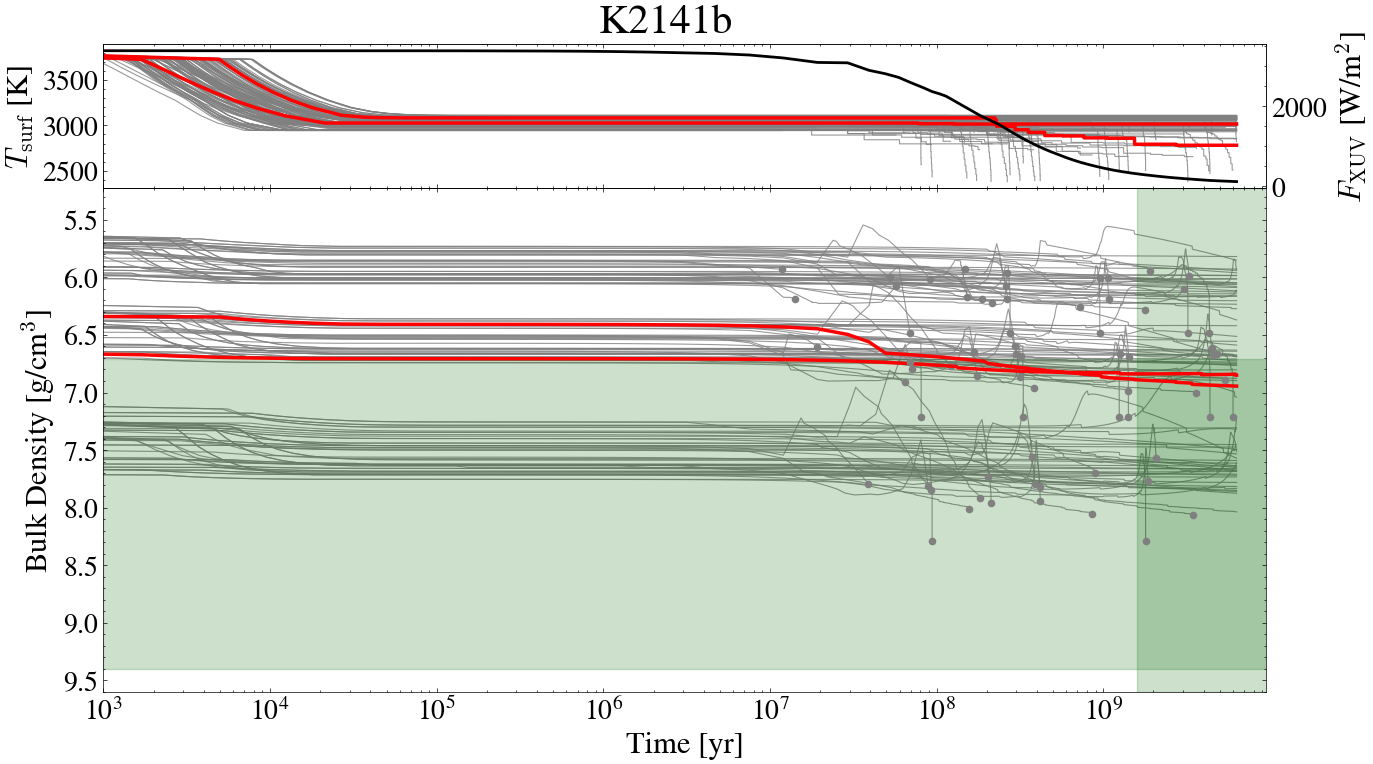

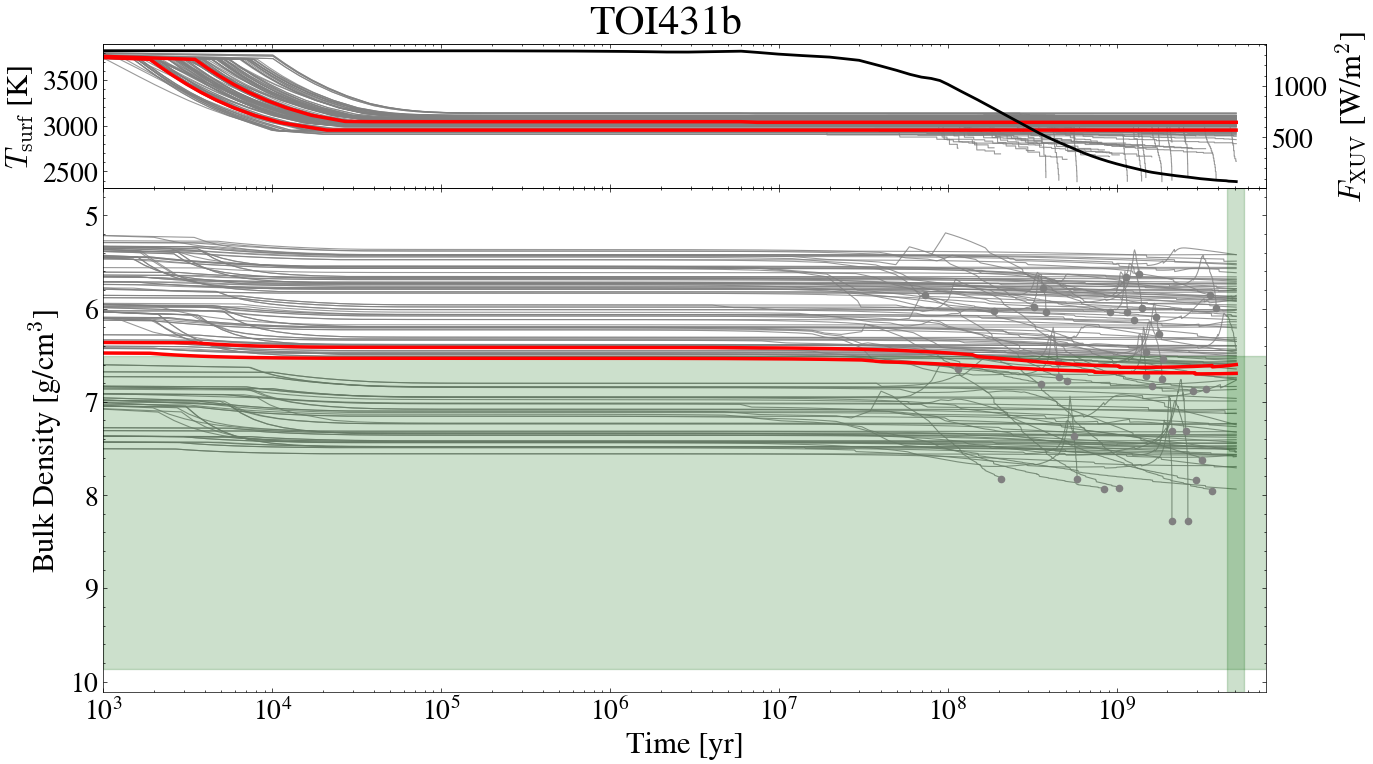

In [11]:
# plot for TOI431 and K2141 using bulk_density_evolution_K2TOI431.pkl
with open('bulk_density_evolution_K2TOI431.pkl', 'rb') as f:
    data_k2toi = pickle.load(f)

highlighted_cases_k2toi = {
    "TOI431": ["case_000034", "case_000082"],
    "K2141":  ["case_000088", "case_000124"],
}

for planet, simulations in data_k2toi.items():
    if planet not in highlighted_cases_k2toi:
        continue
    fig = figure(figsize=(15, 8))
    fig.suptitle(rf"{planet}b", fontsize=30, y=0.98)

    frame   = fig.add_axes([0.125, 0.12, 0.775, 0.63])
    ax_temp = fig.add_axes([0.125, 0.75, 0.775, 0.18], sharex=frame)

    ax_temp.set_ylabel(r'$T_\mathrm{surf}$ [K]')
    ax_temp.set_xscale('log')
    ax_temp.tick_params(labelbottom=False)

    age      = star_age[planet_names.index(planet)]
    age_min  = star_age_min[planet_names.index(planet)]
    age_max  = star_age_max[planet_names.index(planet)]
    bd       = bulk_density_avg[planet_names.index(planet)]
    bd_min   = bulk_density_min[planet_names.index(planet)]
    bd_max   = bulk_density_max[planet_names.index(planet)]

    highlight = highlighted_cases_k2toi.get(planet, [])
    longest_sim = None
    max_time = -np.inf

    for sim in simulations:
        is_highlighted = sim["case"] in highlight
        color   = 'red' if is_highlighted else 'gray'
        lw      = 2.5 if is_highlighted else 0.8
        zorder  = 2 if is_highlighted else 1
        alpha   = 1.0 if is_highlighted else 0.8

        frame.plot(sim["x"], sim["y"]/1000,
                   color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
        if sim["x"][-1] < age:
            frame.scatter(sim["x"][-1], sim["y"][-1]/1000, color=color, s=20, zorder=zorder+1)
        ax_temp.plot(sim["x"], sim["t_surf"],
                     color=color, linestyle='solid', alpha=alpha, linewidth=lw, zorder=zorder)
        ax_temp.grid(False)

        if sim["x"][-1] > max_time:
            max_time = sim["x"][-1]
            longest_sim = sim

    if longest_sim is not None:
        ax2 = ax_temp.twinx()
        ax2.plot(longest_sim["x"], longest_sim["F_xuv"], color='black', alpha=1.0, linewidth=2.0)
        ax2.set_ylabel(r'$F_\mathrm{XUV}$ [W/m$^2$]')
        ax2.tick_params(axis='both', which='major')
        ax2.grid(False)

    #frame.errorbar(age, bd,
    #               xerr=([abs(age_min-age)], [abs(age_max-age)]),
    #               yerr=([abs(bd_min-bd)],   [abs(bd_max-bd)]),
    #               fmt='o', color='red', ecolor='black', elinewidth=3, capsize=5, zorder=5)
    #frame.scatter(age, bd, color='red', zorder=6)
    #instead of error bars, create shaded regions for age and bulk density uncertainties
    frame.axvspan(age_min, age_max, color='darkgreen', alpha=0.2, zorder=1)
    frame.axhspan(bd_min, bd_max, color='darkgreen', alpha=0.2, zorder=1)


    frame.set_xlabel('Time [yr]')
    frame.set_ylabel(r'Bulk Density [g/cm$^3$]')
    frame.set_xscale('log')
    frame.tick_params(axis='both', which='major')
    frame.invert_yaxis()
    frame.set_xlim(1e3, age*1.5)
    frame.grid(False)
    
    savefig(f"thesis-plots/{planet}_bulk_density.pdf", format='pdf')
    show()
    plt.close()


# Atmosphere composition plots

In [12]:
with open('bulk_density_evolution.pkl', 'rb') as f:
    data_all = pickle.load(f)

with open('bulk_density_evolution_LHS.pkl', 'rb') as f:
    data_lhs = pickle.load(f)

with open('bulk_density_evolution_K2TOI431.pkl', 'rb') as f:
    data_k2toi = pickle.load(f)

# for each pickle go through each planet and extract the final vmrs of the highlighted cases
final_vmr_data = {}
for name in planet_names:
    final_vmr_data[name] = {}
    if name == "lhs1478":
        simulations = data_lhs[name]
        highlight = highlighted_cases_lhs
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf']),
                }
    elif name == 'TOI431' or name == 'K2141':
        simulations = data_k2toi[name]
        highlight = highlighted_cases_k2toi.get(name, [])
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf'])
                }
    else:
        simulations = data_all[name]
        highlight = highlighted_cases.get(name, [])
        for sim in simulations:
            if sim["case"] in highlight:
                final_vmr_data[name][sim["case"]] = {
                    "H2O": float(sim['h2o_vmr_final']),
                    "CO2": float(sim['co2_vmr_final']),
                    "O2": float(sim['o2_vmr_final']),
                    "N2": float(sim['n2_vmr_final']),
                    "H2": float(sim['h2_vmr_final']),
                    "SO2": float(sim['so2_vmr_final']),
                    "CH4": float(sim['ch4_vmr_final']),
                    "CO": float(sim['co_vmr_final']),
                    "NH3": float(sim['nh3_vmr_final']),
                    "S2": float(sim['s2_vmr_final']),
                    "H2S": float(sim['h2s_vmr_final']),
                    "surface_pressure": float(sim['p_surf'])
                }
#save final_vmr_data to a new pickle
with open('final_vmr_data.pkl', 'wb') as f:
    pickle.dump(final_vmr_data, f)

In [13]:
# list cases in final_vmr_data[planet_names]
for planet in planet_names:
    print(f"{planet}:")
    for case in final_vmr_data[planet]:
        print(f"  {case}")

HD3167:
  case_000046
  case_000034
K2141:
  case_000088
  case_000124
lhs1478:
  case_000011
  case_000001
TOI431:
  case_000034
  case_000082
TOI500:
  case_000046
  case_000042
TOI561:
  case_000046
TOI1416:
  case_000034
  case_000038
TOI1807:
  case_000022
  case_000026


In [14]:
case1 = final_vmr_data["TOI500"]["case_000046"]
#sort the gases by their vmr in descending order
sorted_gases = sorted(case1.items(), key=lambda x: x[1], reverse=True)
#print the sorted gases and their vmrs
for gas, vmr in sorted_gases:
    print(f"{gas}: {vmr:.2e}")

surface_pressure: 2.17e+02
H2O: 3.50e-01
SO2: 3.02e-01
CO2: 2.37e-01
CO: 3.76e-02
N2: 2.98e-02
S2: 2.73e-02
H2: 8.13e-03
H2S: 5.03e-03
O2: 3.23e-03
NH3: 8.41e-05
CH4: 4.70e-12


In [15]:
results = pd.read_csv('combined_nightside_results.csv',index_col=0)
results

,Planet,Surface Pressure [bar],Atmospheric Components,Hydrogen Inventory [H oceans],Redox State,Integration Time (hours),Number of observations,Observations with bb fit,Mean Temperature,Median Temperature,1-sigma Lower,1-sigma Upper
0,HD3167,10.902882,"SO2, H2O",H10,IW4,345.60,15,18.0,684.793264,899.046517,4.260118,1078.279651
1,HD3167,301.889080,"CO2, N2",H20,IW4,299.52,13,15.0,681.030145,879.790166,22.643581,1080.161661
2,K2141,169.221367,"SO2, H2O",H20,IW4,53.76,8,8.0,832.795583,1075.447271,9.345867,1330.462023
3,K2141,16.028394,"SO2, S2",H30,IW2,53.76,8,8.0,875.997260,1083.199393,410.973486,1343.706663
4,LHS1478,317.212366,"H2O, S2",H05,IW0,468000.00,10000,9850.0,232.036301,314.986889,3.034050,347.804389
5,LHS1478,2693.216197,"CO2, H2O",H05,IW4,468000.00,10000,9850.0,234.972027,317.958710,11.123128,349.009930
7,TOI1416,55.970885,"CO2, SO2",H10,IW4,1176.00,49,53.0,572.883813,766.109011,0.000000,938.521682
8,TOI1416,437.019741,"CO, N2",H20,IW0,840.00,35,37.0,596.799536,796.349503,0.000000,986.541918
9,TOI1807,153.474293,"CO, N2",H10,IW0,277.20,21,21.0,666.128679,910.418318,0.000000,1126.003234
10,TOI1807,13.566413,"SO2, H2O",H5,IW4,422.40,32,32.0,628.129859,852.666742,0.000000,1062.576214


In [16]:
mu_h2O = 18.01528
mu_co2 = 44.01
mu_o2 = 32.00
mu_n2 = 28.0134
mu_h2 = 2.01588
mu_so2 = 64.066
mu_ch4 = 16.04
mu_co = 28.01
mu_nh3 = 17.031
mu_s2 = 64.14
mu_h2s = 34.08

#for all simulations, calculate the mean molecular weight of the atmosphere using the final vmrs and the molecular weights of the species, and save it to a new dictionary
mean_molecular_weight_data = {}
for planet, cases in final_vmr_data.items():
    mean_molecular_weight_data[planet] = {}
    for case, vmrs in cases.items():
        mean_molecular_weight = (vmrs["H2O"] * mu_h2O + vmrs["CO2"] * mu_co2 + vmrs["O2"] * mu_o2 + vmrs["N2"] * mu_n2 + vmrs["H2"] * mu_h2 + vmrs["SO2"] * mu_so2 + vmrs["CH4"] * mu_ch4 + vmrs["CO"] * mu_co + vmrs["NH3"] * mu_nh3 + vmrs["S2"] * mu_s2 + vmrs["H2S"] * mu_h2s) / (vmrs["H2O"] + vmrs["CO2"] + vmrs["O2"] + vmrs["N2"] + vmrs["H2"] + vmrs["SO2"] + vmrs["CH4"] + vmrs["CO"] + vmrs["NH3"] + vmrs["S2"] + vmrs["H2S"])
        mean_molecular_weight_data[planet][case] = mean_molecular_weight

In [36]:
#print each case and its mean molecular weight
for planet, cases in mean_molecular_weight_data.items():
    print(f"{planet}:")
    for case, mmw in cases.items():
        print(f"  {case}: {mmw:.2f} g/mol")

HD3167:
  case_000046: 41.45 g/mol
  case_000034: 53.05 g/mol
K2141:
  case_000088: 57.86 g/mol
  case_000124: 55.35 g/mol
lhs1478:
  case_000011: 36.81 g/mol
  case_000001: 34.93 g/mol
TOI431:
  case_000034: 60.00 g/mol
  case_000082: 54.14 g/mol
TOI500:
  case_000046: 40.00 g/mol
  case_000042: 17.39 g/mol
TOI561:
  case_000046: 25.32 g/mol
TOI1416:
  case_000034: 46.02 g/mol
  case_000038: 26.35 g/mol
TOI1807:
  case_000022: 54.36 g/mol
  case_000026: 25.39 g/mol


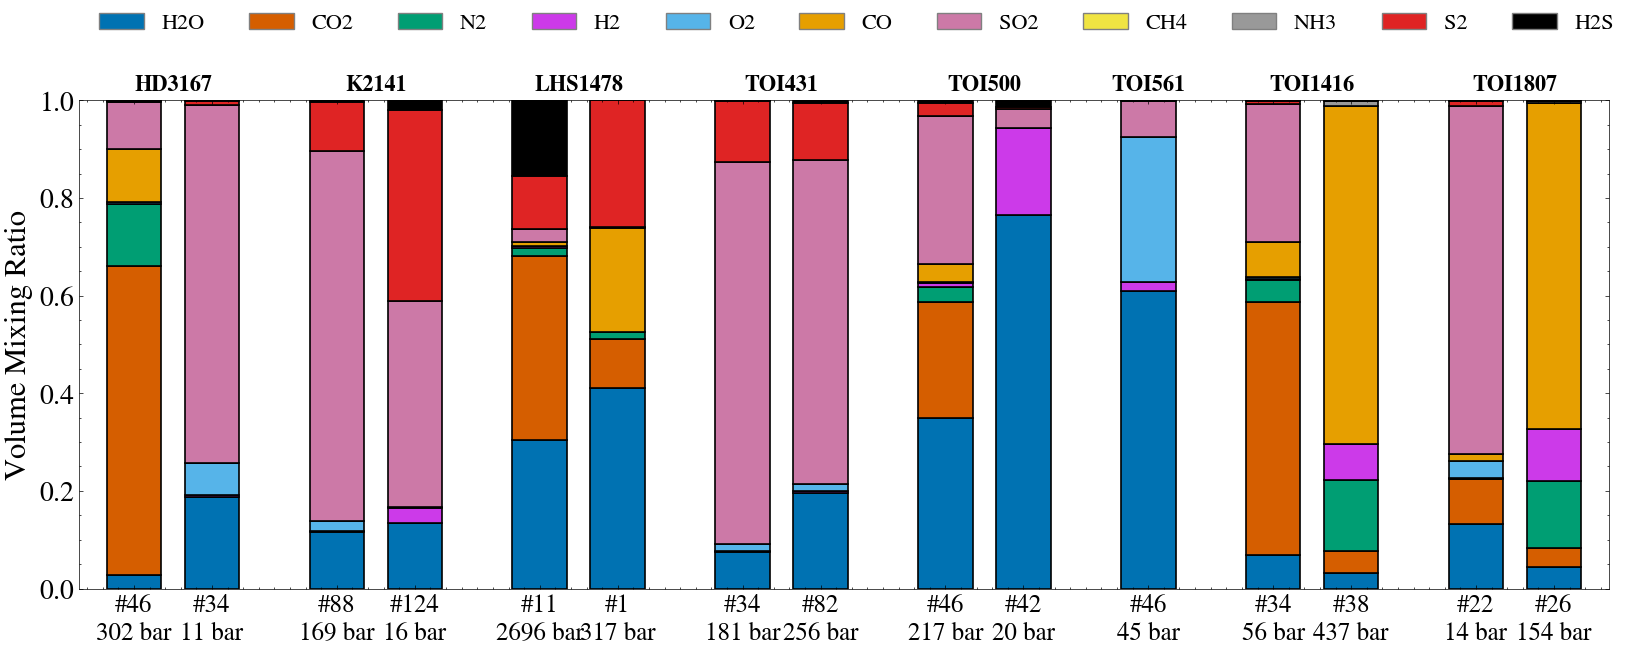

In [17]:
# Atmospheric composition bar chart for all highlighted cases
molecules = ["H2O", "CO2", "N2","H2", "O2", "CO", "SO2", "CH4", "NH3", "S2", "H2S"]

# Okabe-Ito + extras for molecules
mol_colors = {
    "H2O":  "#0072B2",
    "CO2":  "#D55E00",
    "N2":   "#009E73",
    "H2":   "#CC3AE9",
    "O2":   "#56B4E9",
    "CO":   "#E69F00",
    "SO2":  "#CC79A7",
    "CH4":  "#F0E442",
    "NH3":  "#999999",
    "S2":   "#DF2424",
    "H2S":  "#000000"
}

# collect all bars in order: for each planet, one bar per highlighted case
bar_labels = []   # x-tick labels: "case_XXXXXX\nP=XXX bar"
bar_planet = []   # which planet each bar belongs to (for grouping spacing)
bar_vmrs   = []   # list of dicts {molecule: vmr}

for planet in planet_names:
    cases = final_vmr_data.get(planet, {})
    for case, vals in cases.items():
        case_num = int(case.split("_")[-1])
        bar_labels.append(f"#{case_num}\n{vals['surface_pressure']:.0f} bar")
        bar_planet.append(planet)
        bar_vmrs.append(vals)

# build x positions with a gap between planets
x_positions = []
planet_centers = {}
x = 0
prev_planet = None
for i, planet in enumerate(bar_planet):
    if prev_planet is not None and planet != prev_planet:
        x += 0.6  # extra gap between planet groups
    x_positions.append(x)
    x += 1.0
    prev_planet = planet

# compute planet label center positions
for planet in planet_names:
    idxs = [i for i, p in enumerate(bar_planet) if p == planet]
    if idxs:
        planet_centers[planet] = (x_positions[idxs[0]] + x_positions[idxs[-1]]) / 2

fig, ax = plt.subplots(figsize=(max(14, len(bar_labels)*1.2), 7))
ax.grid(False)

for i, (xpos, vmrs) in enumerate(zip(x_positions, bar_vmrs)):
    bottom = 0.0
    for mol in molecules:
        val = vmrs.get(mol, 0.0)
        if val > 0:
            ax.bar(xpos, val, bottom=bottom, width=0.7,
                   color=mol_colors[mol], edgecolor='black', linewidth=1.2)
            bottom += val

# x-axis: case name + pressure below, planet name above as group label
ax.set_xticks(x_positions)
ax.set_xticklabels(bar_labels, ha='center', fontsize=rcParams['xtick.labelsize']-2)

# planet name annotations above the bars
ymax = ax.get_ylim()[1]
for planet, cx in planet_centers.items():
    ax.annotate(planet.upper() if planet == 'lhs1478' else planet, xy=(cx, 1.02), xycoords=('data', 'axes fraction'),
                ha='center', fontweight='bold')

# legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=mol_colors[m], edgecolor='gray', label=m) for m in molecules]
ax.legend(handles=legend_handles, loc='upper left', ncol=len(molecules),
           bbox_to_anchor=(0.0, 1.22), frameon=False)

ax.set_ylabel('Volume Mixing Ratio')
ax.set_ylim(0, 1)
ax.set_xlim(x_positions[0] - 0.7, x_positions[-1] + 0.7)

plt.tight_layout()
savefig('thesis-plots/atmosphere_composition.pdf', format='pdf')
show()
plt.close()


In [18]:
cases = ["46", "34", "88", "124", "1", "11",  ]

# Table of resulting atmospheres

In [19]:
results = pd.read_csv('combined_nightside_results.csv',index_col=0)
#DROP rcolumns 8,9,10,11

results

,Planet,Surface Pressure [bar],Atmospheric Components,Hydrogen Inventory [H oceans],Redox State,Integration Time (hours),Number of observations,Observations with bb fit,Mean Temperature,Median Temperature,1-sigma Lower,1-sigma Upper
0,HD3167,10.902882,"SO2, H2O",H10,IW4,345.60,15,18.0,684.793264,899.046517,4.260118,1078.279651
1,HD3167,301.889080,"CO2, N2",H20,IW4,299.52,13,15.0,681.030145,879.790166,22.643581,1080.161661
2,K2141,169.221367,"SO2, H2O",H20,IW4,53.76,8,8.0,832.795583,1075.447271,9.345867,1330.462023
3,K2141,16.028394,"SO2, S2",H30,IW2,53.76,8,8.0,875.997260,1083.199393,410.973486,1343.706663
4,LHS1478,317.212366,"H2O, S2",H05,IW0,468000.00,10000,9850.0,232.036301,314.986889,3.034050,347.804389
5,LHS1478,2693.216197,"CO2, H2O",H05,IW4,468000.00,10000,9850.0,234.972027,317.958710,11.123128,349.009930
7,TOI1416,55.970885,"CO2, SO2",H10,IW4,1176.00,49,53.0,572.883813,766.109011,0.000000,938.521682
8,TOI1416,437.019741,"CO, N2",H20,IW0,840.00,35,37.0,596.799536,796.349503,0.000000,986.541918
9,TOI1807,153.474293,"CO, N2",H10,IW0,277.20,21,21.0,666.128679,910.418318,0.000000,1126.003234
10,TOI1807,13.566413,"SO2, H2O",H5,IW4,422.40,32,32.0,628.129859,852.666742,0.000000,1062.576214


In [20]:
mean_molecular_weight_data

{'HD3167': {'case_000046': 41.45234826886619,
  'case_000034': 53.05247271804008},
 'K2141': {'case_000088': 57.86251080939287, 'case_000124': 55.35146444895296},
 'lhs1478': {'case_000011': 36.81364559001949,
  'case_000001': 34.93206623831668},
 'TOI431': {'case_000034': 60.003437538727596,
  'case_000082': 54.13529196559052},
 'TOI500': {'case_000046': 39.99649201743114,
  'case_000042': 17.389556736774118},
 'TOI561': {'case_000046': 25.322500084774234},
 'TOI1416': {'case_000034': 46.02444543566947,
  'case_000038': 26.34706146636201},
 'TOI1807': {'case_000022': 54.3553672988508,
  'case_000026': 25.394483759928306}}

In [21]:
atmos_table = pd.DataFrame({
    "Planet": results["Planet"],
    "Case": 0,
    "Hydrogen Inventory [H oceans]": results["Hydrogen Inventory [H oceans]"],
    "Redox State": results["Redox State"],
    "Sulfur Inventory [S/H ratio]": 0,
    "Surface Pressure [bar]": results["Surface Pressure [bar]"],
    "Atmospheric Composition": results["Atmospheric Components"],
    "Mean Molecular Weight [g/mol]": 0})

In [22]:
#optional to create this table

# Visualization of one post-processed simulation

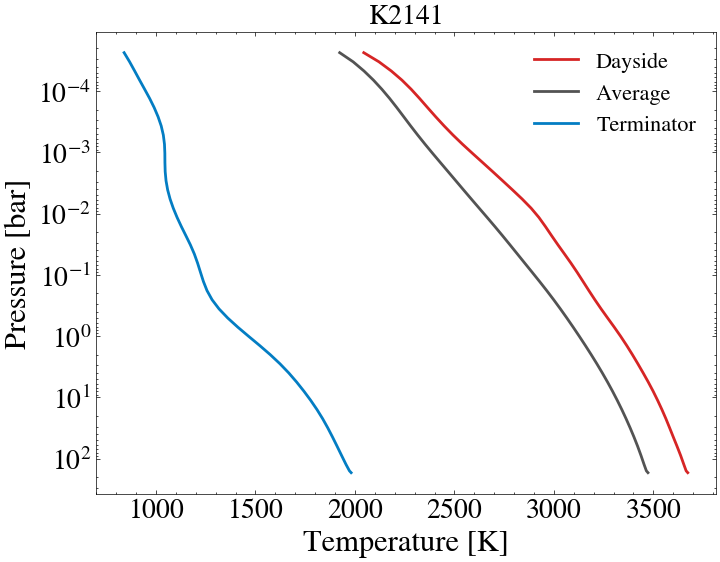

In [25]:
name = 'K2141'
TP_file = f'PLANETS/{name}/H20_IW4_0001_S40_TP.csv'
data = pd.read_csv(TP_file)

fig = figure(figsize=(8, 6))
frame = fig.add_subplot(1, 1, 1)
pressure = data['Pressure (Pa)']/1e5 #convert to bar

dayside_temp = data['Substellar Temperature (K)']
frame.plot(dayside_temp, pressure, color="#D62525", linestyle='solid', linewidth=2, label='Dayside')

average_temp = data['Average Temperature (K)']
frame.plot(average_temp, pressure, color="#535353", linestyle='solid', linewidth=2, label='Average')

terminator_temp = data['Terminator Temperature (K)']
frame.plot(terminator_temp, pressure, color="#037DC3", linestyle='solid', linewidth=2, label='Terminator')

frame.set_xlabel('Temperature [K]')
frame.set_ylabel('Pressure [bar]')

frame.set_title(f'{name}', fontsize=20)
frame.legend(loc='upper right')
frame.invert_yaxis()
frame.set_yscale('log')
frame.grid(False)
savefig(f'thesis-plots/example_TP_profile.pdf', format='pdf')
show()

# Dayside and Nightside emission comparison for HD3167

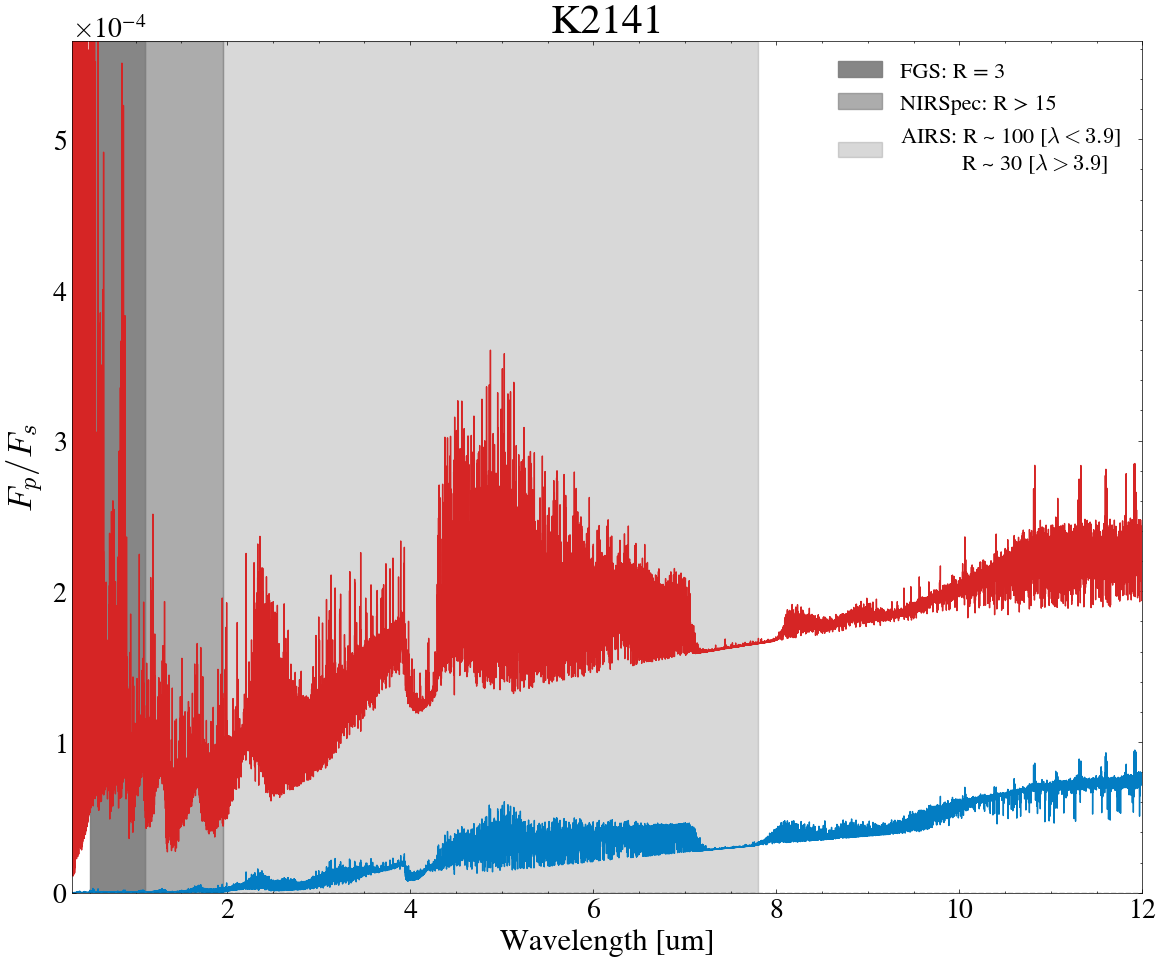

In [26]:

name = 'K2141'
eclipses = 1
binning = False
sigma = 1

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = eclipses #number of observed eclipses

    plt.figure(figsize=(12,10))
    #plot of spectrum from TauREx
    plt.plot(wlgrid, fpfs, color="#D62525")
    plt.plot(wlgrid_t, fpfs_t, color='#037DC3')

    yerr = noise / np.sqrt(N) * sigma # sigma confidence interval

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    #if ymin - pad < 0:
    #    plt.ylim(0, ymax + pad)
    # else:
    plt.ylim(ymin - pad, ymax + pad)

    # target integration time
    time = planet_transit[planet_names.index(name)] * (N + 1.5) #in hours

    #total telescope time
    t_time = N * planet_period[planet_names.index(name)] #in hours


    #plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)

    plt.axvspan(0.5,1.1, color='gray', alpha=0.95, zorder=0, label = 'FGS: R = 3')
    plt.axvspan(1.1,1.95, color = 'gray', alpha=0.65, zorder=0, label = 'NIRSpec: R > 15')
    plt.axvspan(1.95,7.8, color = 'gray', alpha=0.30, zorder=0, label = 'AIRS: R ~ 100 [$\lambda<3.9$] \n           R ~ 30 [$\lambda>3.9$]')
    
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))


    plt.xlabel("Wavelength [um]")
    plt.ylabel(r"$F_p/F_s$",fontsize=25)
    #plt.xscale("log")
    plt.xlim(0.3, 12)
    plt.ylim(0,None)
    plt.title(f"{name}",fontsize=30) #- {N} eclipses - Integration time: {time:.2f} hours")
    plt.tight_layout()
    plt.hlines(y=0, xmin = -1, xmax = 12, color='black', linestyle='--', alpha=0.5)
    #plt.yscale("log")
    plt.legend(loc='upper right')
    plt.grid(False)


    savefig(f'thesis-plots/{name}_emission_comparison.pdf', format='pdf')

    show()
    close()
    break

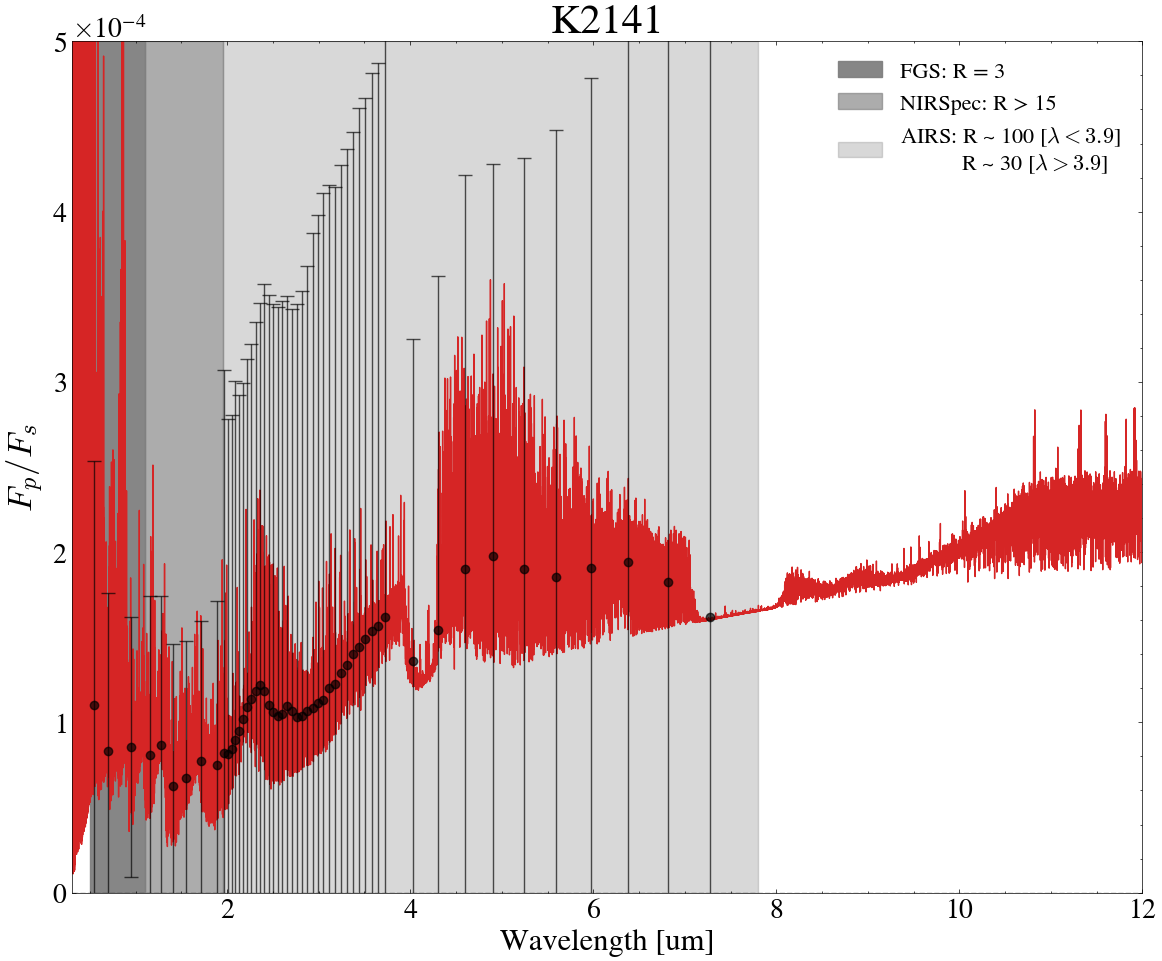

In [29]:
# Dayside and Nightside emission comparison for HD3167

name = 'K2141'
eclipses = 1
binning = False
sigma = 1

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)

    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = eclipses #number of observed eclipses

    plt.figure(figsize=(12,10))
    #plot of spectrum from TauREx
    plt.plot(wlgrid, fpfs, color='#D62525')
    #plt.plot(wlgrid_t, fpfs_t, color='#0072B2')

    yerr = noise / np.sqrt(N) * sigma # sigma confidence interval

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    #if ymin - pad < 0:
    #    plt.ylim(0, ymax + pad)
    # else:
    plt.ylim(ymin - pad, ymax + pad)

    # target integration time
    time = planet_transit[planet_names.index(name)] * (N + 1.5) #in hours

    #total telescope time
    t_time = N * planet_period[planet_names.index(name)] #in hours

    plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)

    #plt.axvspan(0.5,1.1, color='cyan', alpha=0.75, zorder=0, label = 'FGS: R = 3')
    #plt.axvspan(1.1,1.95, color = 'pink', alpha=0.95, zorder=0, label = 'NIRSpec: R > 15')
    #plt.axvspan(1.95,7.8, color = 'darkgreen', alpha=0.35, zorder=0, label = 'AIRS: R ~ 100 [$\lambda<3.9$] \n           R ~ 30 [$\lambda>3.9$]')
    
    #plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    plt.axvspan(0.5,1.1, color='gray', alpha=0.95, zorder=0, label = 'FGS: R = 3')
    plt.axvspan(1.1,1.95, color = 'gray', alpha=0.65, zorder=0, label = 'NIRSpec: R > 15')
    plt.axvspan(1.95,7.8, color = 'gray', alpha=0.3, zorder=0, label = 'AIRS: R ~ 100 [$\lambda<3.9$] \n           R ~ 30 [$\lambda>3.9$]')

    plt.xlabel("Wavelength [um]")
    plt.ylabel(r"$F_p/F_s$",fontsize=25)
    #plt.xscale("log")
    plt.xlim(0.3, 12)
    plt.ylim(0,0.0005)
    plt.title(f"{name}",fontsize=30) #- {N} eclipses - Integration time: {time:.2f} hours")
    plt.tight_layout()
    plt.hlines(y=0, xmin = -1, xmax = 12, color='black', linestyle='--', alpha=0.5)
    #plt.yscale("log")
    plt.legend(loc='upper right')
    plt.grid(False)

    savefig(f'thesis-plots/{name}_emission_comparison_with_noise.pdf', format='pdf')

    show()
    close()
    break

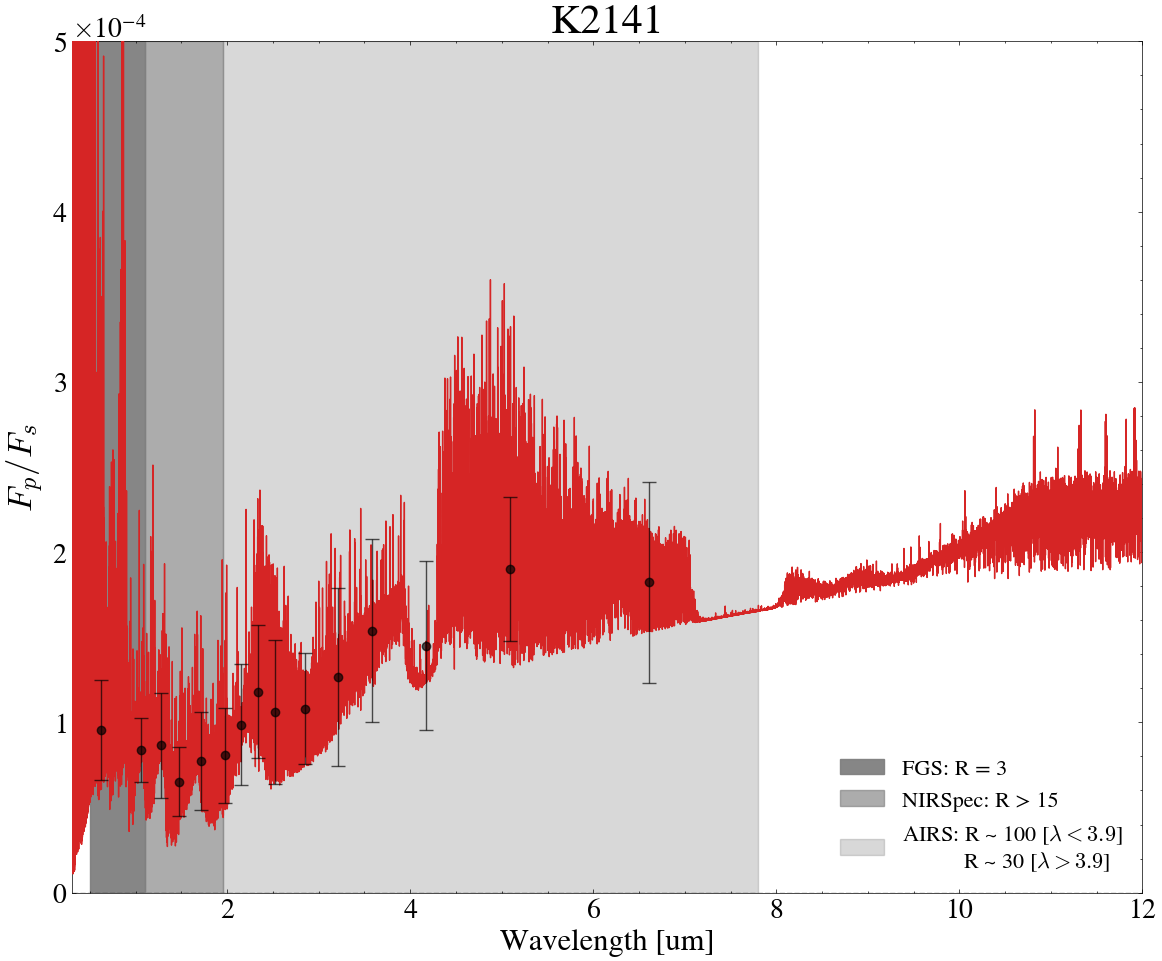

In [32]:
# ── Same emission spectrum with optimised binning applied ─────────────────────
import ast as _ast

# Load binning indices for this planet/simulation
_em_idx_csv  = f'PLANETS/{name}/{os.path.basename(simulation_folder)}_binning_indices.csv'
_em_idx_data = pd.read_csv(_em_idx_csv)
_em_l1 = _ast.literal_eval(_em_idx_data['Indices_l1'].iloc[0])
_em_l2 = _ast.literal_eval(_em_idx_data['Indices_l2'].iloc[0])
_em_l3 = _ast.literal_eval(_em_idx_data['Indices_l3'].iloc[0])

_em_eclipses = int(_em_idx_data['Observations'].iloc[0])
_em_yerr     = noise / np.sqrt(_em_eclipses) * sigma

# output is (wl_array, flux_array, ...) from fb.bindown() in the cell above
# bindown_multiple expects this full tuple as its first argument

# --- Apply L1 binning ---
_em_pts_l1  = [(wl[i], wb[i], wl[j], wb[j]) for i, j in _em_l1]
_em_used_l1 = {k for pair in _em_l1 for k in pair}
_em_res1    = bindown_multiple(output, noise, wl, output[1], _em_eclipses, name, *_em_pts_l1)

_em_combined = []
for k in range(len(wl)):
    if k not in _em_used_l1:
        _em_combined.append((wl[k], wb[k], output[1][k], _em_yerr[k]))
for out in _em_res1:
    _em_combined.append((out[2], out[5], out[3], out[4]))
_em_combined.sort(key=lambda x: x[0])

# --- Apply L2 binning ---
_em_pts_l2  = [(_em_combined[i][0], _em_combined[i][1], _em_combined[j][0], _em_combined[j][1])
               for i, j in _em_l2]
_em_used_l2 = {k for pair in _em_l2 for k in pair}
_em_res2    = bindown_multiple(output, noise, wl, output[1], _em_eclipses, name, *_em_pts_l2)

_em_combined_l2 = []
for k, keep in enumerate([i not in _em_used_l2 for i in range(len(_em_combined))]):
    if keep:
        _em_combined_l2.append(_em_combined[k])
for out in _em_res2:
    _em_combined_l2.append((out[2], out[5], out[3], out[4]))
_em_combined_l2.sort(key=lambda x: x[0])

# --- Apply L3 binning ---
_em_pts_l3  = [(_em_combined_l2[i][0], _em_combined_l2[i][1], _em_combined_l2[j][0], _em_combined_l2[j][1])
               for i, j in _em_l3]
_em_used_l3 = {k for pair in _em_l3 for k in pair}
_em_res3    = bindown_multiple(output, noise, wl, output[1], _em_eclipses, name, *_em_pts_l3)

_em_final = []
for k, keep in enumerate([i not in _em_used_l3 for i in range(len(_em_combined_l2))]):
    if keep:
        _em_final.append((_em_combined_l2[k][0], _em_combined_l2[k][2], _em_combined_l2[k][3]))
for out in _em_res3:
    _em_final.append((out[2], out[3], out[4]))
_em_final.sort(key=lambda x: x[0])

_em_wl_f  = np.array([p[0] for p in _em_final])
_em_val_f = np.array([p[1] for p in _em_final])
_em_err_f = np.array([p[2] for p in _em_final])

# --- Plot ---
plt.figure(figsize=(12, 10))
plt.plot(wlgrid, fpfs, color='#D62525', zorder=5)
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.axvspan(0.5,  1.1,  color='gray',      alpha=0.95, zorder=0, label='FGS: R = 3')
plt.axvspan(1.1,  1.95, color='gray',      alpha=0.65, zorder=0, label='NIRSpec: R > 15')
plt.axvspan(1.95, 7.8,  color='gray', alpha=0.3, zorder=0,
            label=r'AIRS: R ~ 100 [$\lambda<3.9$]' + '\n' + r'           R ~ 30 [$\lambda>3.9$]')

plt.errorbar(_em_wl_f, _em_val_f, yerr=_em_err_f,
             capsize=5, fmt='o', color='black', alpha=0.67, zorder=6)

_y_all = np.concatenate([_em_val_f + _em_err_f, _em_val_f - _em_err_f])
_pad   = 0.0001 * (_y_all.max() - _y_all.min())
plt.ylim(_y_all.min() - _pad, _y_all.max() + _pad)

plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.xlabel('Wavelength [um]')
plt.ylabel(r'$F_p/F_s$', fontsize=25)
plt.xlim(0.3, 12)
plt.ylim(0,0.0005)
plt.hlines(y=0, xmin=-1, xmax=12, color='black', linestyle='--', alpha=0.5)
plt.title(f'{name}', fontsize=30)
plt.legend(loc='lower right')
plt.grid(False)
plt.tight_layout()
savefig(f'thesis-plots/{name}_emission_comparison_optimised_binning.pdf', format='pdf')
plt.show()


# Example of Nightside Detection

In [27]:
results

,Planet,Surface Pressure [bar],Atmospheric Components,Hydrogen Inventory [H oceans],Redox State,Integration Time (hours),Number of observations,Observations with bb fit,Mean Temperature,Median Temperature,1-sigma Lower,1-sigma Upper
0,HD3167,10.902882,"SO2, H2O",H10,IW4,345.60,15,18.0,684.793264,899.046517,4.260118,1078.279651
1,HD3167,301.889080,"CO2, N2",H20,IW4,299.52,13,15.0,681.030145,879.790166,22.643581,1080.161661
2,K2141,169.221367,"SO2, H2O",H20,IW4,53.76,8,8.0,832.795583,1075.447271,9.345867,1330.462023
3,K2141,16.028394,"SO2, S2",H30,IW2,53.76,8,8.0,875.997260,1083.199393,410.973486,1343.706663
4,LHS1478,317.212366,"H2O, S2",H05,IW0,468000.00,10000,9850.0,232.036301,314.986889,3.034050,347.804389
5,LHS1478,2693.216197,"CO2, H2O",H05,IW4,468000.00,10000,9850.0,234.972027,317.958710,11.123128,349.009930
7,TOI1416,55.970885,"CO2, SO2",H10,IW4,1176.00,49,53.0,572.883813,766.109011,0.000000,938.521682
8,TOI1416,437.019741,"CO, N2",H20,IW0,840.00,35,37.0,596.799536,796.349503,0.000000,986.541918
9,TOI1807,153.474293,"CO, N2",H10,IW0,277.20,21,21.0,666.128679,910.418318,0.000000,1126.003234
10,TOI1807,13.566413,"SO2, H2O",H5,IW4,422.40,32,32.0,628.129859,852.666742,0.000000,1062.576214


In [35]:
# input parameters
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
name = planet_names[1]

# was: eclipses = 35
eclipses = np.arange(7,10, 1, dtype=int)  # <- array input

binning = True
sigma = 1

new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

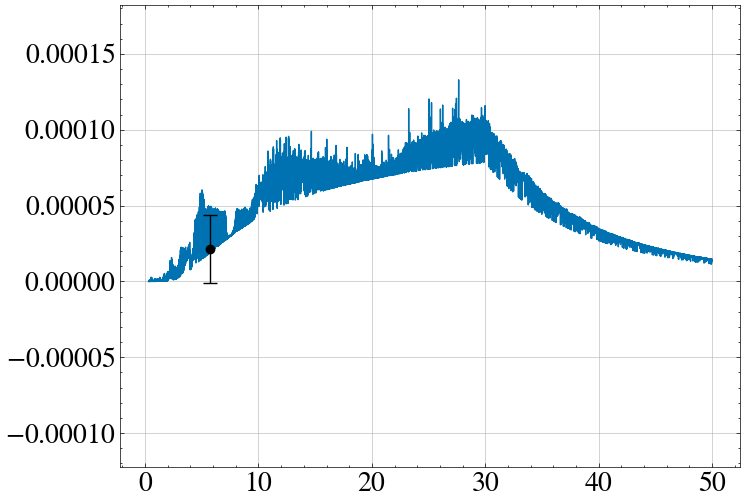

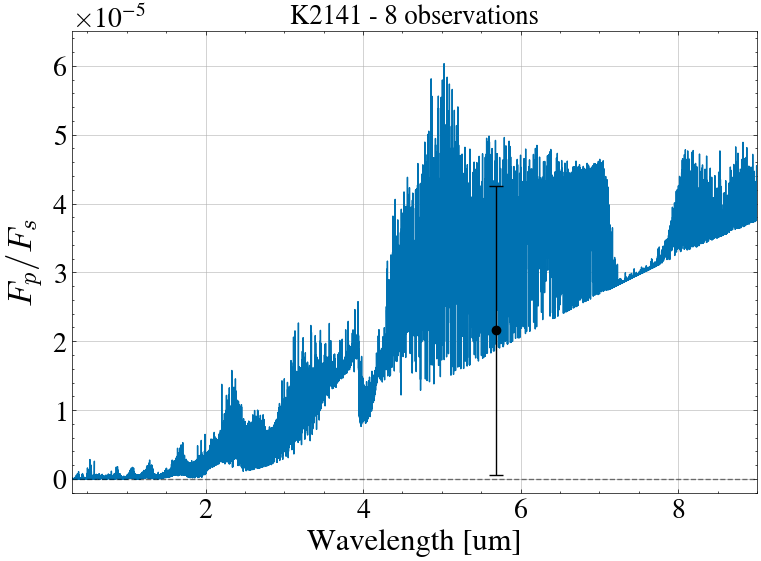

In [39]:
for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_sma=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    #build emission model at the terminator
    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-H2','N2-H2O','O2-CO2']))
    em_terminator.add_contribution(RayleighContribution())

    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid_t = 10000/wngrid_t[::-1]
    fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional
    # instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output_t = fb.bindown(wlgrid_t, fpfs_t)
    
    for N in eclipses:
        detection = False
    
        plt.figure(figsize=(8,6))
        yerr = noise / np.sqrt(N) * sigma
    
        y_all = np.concatenate([output_t[1] + yerr, output_t[1] - yerr])
        ymin, ymax = y_all.min(), y_all.max()
        pad = 0.0001 * (ymax - ymin)
        plt.ylim(ymin - pad, ymax + pad)
        plt.plot(wlgrid_t, fpfs_t, color='#0072B2')
    
        time = planet_transit[planet_names.index(name)] + 1.5 * planet_transit[planet_names.index(name)]
        #t_time = planet_period[planet_names.index(name)]*24 + (N-2)*time
        total_time = planet_period[planet_names.index(name)] * 24 * N
    
        if binning:
            results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points)
            new_points_t = make_next_level_points(results_t)
            results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_t)
            new_points_level2_t = make_next_level_points(results_level2_t)
            results_level3_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_level2_t)
    
            for out in results_level3_t:
                plt.errorbar(out[2], out[3], yerr=out[4]*sigma, capsize=5, fmt='o', color='black')
                if out[3] - out[4]*sigma > 0:
                    detection = True
        else:
            plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='black', alpha=0.67)
            if np.any(output_t[1] - noise/np.sqrt(N)*sigma > 0):
                detection = True

        if detection == True:
            plt.xlabel("Wavelength [um]")
            plt.ylabel(r"$F_p/F_s$",fontsize=25)
            plt.xlim(0.3, 9)
            plt.ylim(-0.2e-5, 6.5e-5)
            plt.title(f"{name} - {N} observations")
            plt.tight_layout()
            plt.hlines(y=0, xmin=0.3, xmax=9, color='black', linestyle='--', alpha=0.5)
            plt.savefig(f"thesis-plots/{name}_{N}.pdf", format='pdf')
            show()
            close()
            break

    break

# Blackbody fit

In [41]:
# Input parameters

name = planet_names[1] # <- input planet name
mass = planet_masses[planet_names.index(name)] #Earth masses
distance = planet_distances[planet_names.index(name)] #AU
period = planet_period[planet_names.index(name)] #days
radius = planet_radius[planet_names.index(name)] #Earth radii
#convert to Jupiter mass and radius
mass_jup = mass / 317.8
transit = planet_transit[planet_names.index(name)] #hours

star_temp = star_temperature[planet_names.index(name)] #Kelvin
star_rad = star_radius[planet_names.index(name)] #Solar radii
metallicity = star_metallicity[planet_names.index(name)] #[Fe/H]
logg = star_logg[planet_names.index(name)]
age = star_age[planet_names.index(name)] #Gyr

#star spectra
star = PhoenixStar(temperature=star_temp, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

#binning and noise
binning = False #binning on or off
sigma = 1 #sigma level for error bars 

#binning points
new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

def planet_spectra(wavelength, temperature):

    h = 6.62607015e-34
    c = 299792458
    k = 1.380649e-23

    wl_m = wavelength * 1e-6

    # planet Planck
    Bp = (2*h*c**2) / (wl_m**5 * (np.exp(h*c/(wl_m*k*temperature)) - 1))

    # star Planck (same spectral variable)
    Bs = (2*h*c**2) / (wl_m**5 * (np.exp(h*c/(wl_m*k*star_temp)) - 1))

    r_ratio = ((radius_jup * astropy.constants.R_jup.value)**2) / ((star_rad * astropy.constants.R_sun.value)**2)

    return r_ratio * Bp / Bs

#save all simulation folders in each planet folder
for folder in os.listdir(f"PLANETS/{name}/"):
        if os.path.isdir(os.path.join(f"PLANETS/{name}/", folder)):
            print(folder)

H30_IW2_0001_S40
H20_IW4_0001_S40


In [44]:
folder = 'H30_IW2_0001_S40' # <- input folder name for simulation

#open temperature profile of the terminator for the given simulation
TP = pd.read_csv(f"PLANETS/{name}/{folder}_TP.csv")
P = np.array(TP['Pressure (Pa)']) / 1e5 #convert to bar
T = np.array(TP['Terminator Temperature (K)']) #Kelvin

simulation_folder = os.path.join(f"PLANETS/{name}/", folder)

#set-up directories and paths
outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                            temp_col=1, press_col=0,
                            temp_units='K', press_units='Pa',
                            delimiter = ',')

atm_file = None
for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
    if file.endswith("atm.nc"):
        atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
        #save filename without extension
        filename = os.path.splitext(atm_file)[0]
        break

ds = xr.open_dataset(atm_file)

#extract gas names
gases = np.array(ds['gases'])
gases = [m.decode().strip() for m in ds["gases"].values]
vmr = np.array(ds['x_gas'])

pressure = np.array(ds['p']) #pressure in Pa
pmax = pressure.max()
pmin = pressure.min()

radius = float(ds['planet_radius']) #planet radius in m
#convert to Jupiter radii
radius_jup = radius / astropy.constants.R_jup.value

#get mixing ratio of each molecule
H2O_x = float(vmr[:, gases.index('H2O')][0])
CO2_x = float(vmr[:, gases.index('CO2')][0])
CH4_x = float(vmr[:, gases.index('CH4')][0])
CO_x = float(vmr[:, gases.index('CO')][0])
NH3_x = float(vmr[:, gases.index('NH3')][0])
N2_x = float(vmr[:, gases.index('N2')][0])
SO2_x = float(vmr[:, gases.index('SO2')][0])
S2_x = float(vmr[:, gases.index('S2')][0])
O2_x = float(vmr[:, gases.index('O2')][0])
H2_x = float(vmr[:, gases.index('H2')][0])
H2S_x = float(vmr[:, gases.index('H2S')][0])

#define chemistry
chemistry = TaurexChemistry(fill_gases=["N2"])

# check that the sum of all vmr is less or equal to 1
total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
if total_vmr > 1:
    #renormalize the vmr values
    H2O_x = H2O_x / total_vmr
    CO2_x = CO2_x / total_vmr
    CH4_x = CH4_x / total_vmr
    CO_x = CO_x / total_vmr
    NH3_x = NH3_x / total_vmr
    N2_x = N2_x / total_vmr
    SO2_x = SO2_x / total_vmr
    S2_x = S2_x / total_vmr
    O2_x = O2_x / total_vmr
    H2_x = H2_x / total_vmr
    H2S_x = H2S_x / total_vmr

chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

#convert to jupiter masses without mutating input mass
mass_jup = mass / 317.8
#set-up planet in Jupiter masses and radii
planet = Planet(planet_mass=mass_jup, planet_radius= radius_jup, planet_distance=distance)

star = PhoenixStar(temperature=star_temp, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

#build emission model at the terminator
em_terminator = EmissionModel( 
planet=planet,
temperature_profile=temp_profile_terminator,
chemistry=chemistry,
pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
star=star,
)

em_terminator.add_contribution(AbsorptionContribution())
em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
em_terminator.add_contribution(RayleighContribution())

em_terminator.build()

#wavenumber grid, flux ratio, and transit depth
wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

wlgrid_t = 10000/wngrid_t[::-1]
fpfs_t = fpfs_t[::-1]

#read-in Ariel noise model
if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
    file = f"ARIEL/arielrad_{name}/tier2.csv"

ariel = pd.read_csv(file,skiprows=6)
wl = np.array(ariel['Wavelength [um]'])
wb = np.array(ariel['Bandwidth [um]'])
noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

# instantiate flux binner with Ariel's wavelength binning
fb = FluxBinner(wl, wb)
output_t = fb.bindown(wlgrid_t, fpfs_t)
wl, val, err, *_ = output_t

locals()[f"T_{name}_{os.path.basename(simulation_folder)}"] = []

#extract star spectrum on the SAME model grid as fpfs_t
star_flux_model = np.asarray(star.spectralEmissionDensity)
star_wl_model = 10000 / np.asarray(wngrid_t)

n_star = min(star_flux_model.size, star_wl_model.size)
star_flux_model = star_flux_model[:n_star]
star_wl_model = star_wl_model[:n_star]

sort_idx = np.argsort(star_wl_model)
star_wl_model = star_wl_model[sort_idx]
star_flux_model = star_flux_model[sort_idx]

output_star = fb.bindown(star_wl_model, star_flux_model)
star_wl_binned, star_flux_binned, star_err, *_ = output_star


def _mean_model_positive(T):
    if T <= 0:
        return 0.0
    return float(np.mean(planet_spectra(wl, T)))


def _temperature_from_mean_flux(mean_flux):
    target = abs(float(mean_flux))
    if np.isclose(target, 0.0):
        return 0.0

    model_max = _mean_model_positive(3000.0)
    if target >= model_max:
        return 3000.0

    return brentq(lambda T: _mean_model_positive(T) - target, 1e-6, 3000.0)


def signed_planet_spectra(wavelength, temperature):
    T_value = float(np.asarray(temperature).item())

    if np.isclose(T_value, 0.0):
        return np.zeros_like(wavelength, dtype=float)

    return np.sign(T_value) * planet_spectra(wavelength, abs(T_value))


#find lowest number of obs before 1-sigma lower limit for temperature is above 0K
for obs in np.arange(7,10,1):
    locals()[f"T_{name}_{os.path.basename(simulation_folder)}"] = []

    sigma_obs = noise / np.sqrt(obs)

    for n in range(1000):
        val_noise = np.random.normal(loc=val, scale=sigma_obs)

        # Shift the noisy spectrum only as a numerical convenience.
        # The same offset is added to the fitted model, so the recovered
        # temperature still corresponds to the unshifted spectrum.
        delta = float(max(0.0, -np.min(val_noise)))
        val_shifted = val_noise + delta

        mean_guess = float(np.mean(val_noise))
        T_guess = _temperature_from_mean_flux(mean_guess)
        if mean_guess < 0:
            T_guess *= -1.0
        if np.isclose(T_guess, 0.0):
            T_guess = -10.0 if mean_guess < 0 else 10.0

        p0 = [T_guess]
        bounds = ([-3000.0], [3000.0])
        try:
            popt, pcov = curve_fit(
                lambda wavelength, temperature: signed_planet_spectra(wavelength, temperature) + delta,
                wl,
                val_shifted,
                p0=p0,
                sigma=sigma_obs,
                absolute_sigma=True,
                bounds=bounds,
            )
            T_true = float(popt[0])
        except (RuntimeError, ValueError):
            T_true = 0.0

        locals()[f"T_{name}_{os.path.basename(simulation_folder)}"].append(T_true)

    temperature_dist = np.array(locals()[f"T_{name}_{os.path.basename(simulation_folder)}"])

    #find mean and std of temperature distribution
    mean_temp = np.mean(temperature_dist)
    std_temp = np.std(temperature_dist)
    median_temp = np.median(temperature_dist)

    #find 1 sigma confidence interval
    q_low_1, q_high_1 = np.percentile(temperature_dist, [15.865, 84.135])

    #find 3 sigma confidence interval
    q_low, q_high = np.percentile(temperature_dist, [0.135, 99.865])

    # find 5 sigma confidence interval
    q_low_5, q_high_5 = np.percentile(temperature_dist, [0.000057, 99.999943])

    print(f"Analysed for {obs} observations. Mean temperature: {mean_temp:.2f} K, 1-sigma lower limit: {q_low_1:.2f} K, 1-sigma upper limit: {q_high_1:.2f} K")

    if q_low_1 > 0:
        print(f"{obs} observations for {name} - {os.path.basename(simulation_folder)}; Mean temperature: {mean_temp:.2f} K, 1-sigma lower limit: {q_low_1:.2f} K, 1-sigma upper limit: {q_high_1:.2f} K")

        break

Analysed for 7 observations. Mean temperature: 774.05 K, 1-sigma lower limit: -43.40 K, 1-sigma upper limit: 1333.65 K
Analysed for 8 observations. Mean temperature: 814.61 K, 1-sigma lower limit: 9.96 K, 1-sigma upper limit: 1303.73 K
8 observations for K2141 - H30_IW2_0001_S40; Mean temperature: 814.61 K, 1-sigma lower limit: 9.96 K, 1-sigma upper limit: 1303.73 K


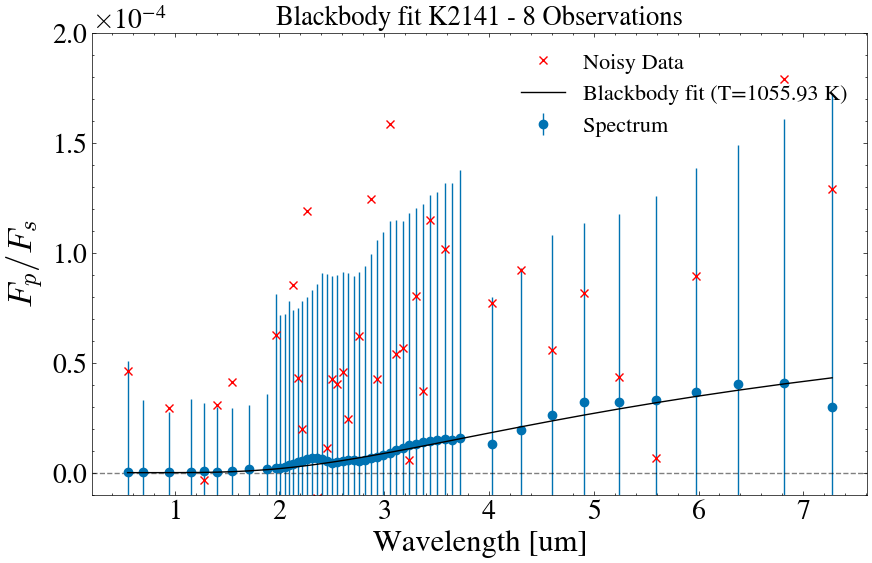

In [47]:
#show the fit of the planet spectra with the mean temperature
plt.figure(figsize=(10, 6))
plt.errorbar(wl, val, yerr=noise/np.sqrt(obs), fmt='o', label='Spectrum', color='#0072B2')
plt.plot(wl,val_noise, 'x', label='Noisy Data', color='red')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.plot(wl, signed_planet_spectra(wl, median_temp), label=f'Blackbody fit (T={median_temp:.2f} K)', color='black',zorder=5)
plt.ylim(-1e-5,20e-5)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
#plt.yscale('log')
plt.xlabel('Wavelength [um]')
plt.ylabel(r'$F_p/F_s$',fontsize=25)
plt.title(f'Blackbody fit {name} - {obs} Observations')
plt.grid()
plt.legend()
savefig(f'thesis-plots/{name}_{obs}_blackbody_fit.pdf', format='pdf')
plt.show()

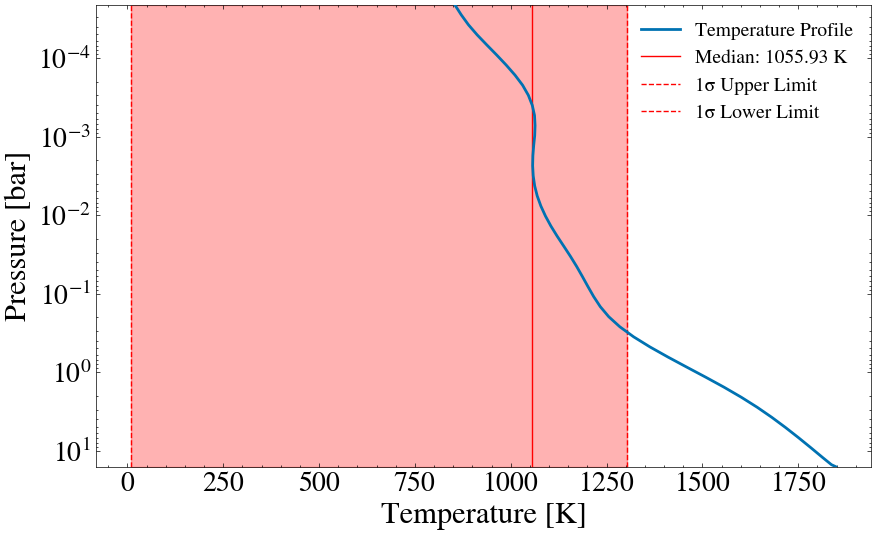

In [54]:
#compare retrieved temperature to the true temperature from the model
fig = figure(figsize=(10, 6))
frame = fig.add_subplot(1, 1, 1)

frame.plot(T,P, label='Temperature Profile', color='#0072B2',zorder=10,linewidth=2)
frame.axvline(median_temp, color='red', linewidth=1, label=f'Median: {median_temp:.2f} K')
frame.axvline(q_high_1, color='red', linestyle='dashed', linewidth=1, label=f'1σ Upper Limit')
frame.axvline(q_low_1, color='red', linestyle='dashed', linewidth=1, label=f'1σ Lower Limit')
#shaded region for 1 sigma confidence interval
frame.fill_betweenx(P, q_low_1, q_high_1, color='red', alpha=0.3)

frame.invert_yaxis()
frame.set_ylim(P.max(), P.min())
frame.set_xlabel('Temperature [K]')
frame.set_ylabel('Pressure [bar]')
frame.set_title(f'')
frame.legend(loc='upper right', fontsize =14)
frame.grid(False)
frame.set_yscale('log')
savefig(f'thesis-plots/{name}_{obs}_temperature_comparison.pdf', format='pdf')
show()

# Phase Curves

In [56]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_transit = [n * 3600 for n in planet_transit] #hours to seconds
T_transit_hours = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data

star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

name = planet_names[1]
H = '30'
iw = '2'
eff = '0001'

#optional
S = '40'

N_pc = 8

In [57]:
mass = planet_masses[planet_names.index(name)] #Earth masses
#convert to jupiter masses
mass_jup = mass / 317.8
print(mass_jup)
#semi-major axis
a = planet_distances[planet_names.index(name)] #AU

radius = planet_radius[planet_names.index(name)] #planet radius in m

#convert to Jupiter radii
radius_jup = radius * (astropy.constants.R_earth.value / astropy.constants.R_jup.value)
print(radius_jup)


#set-up planet in Jupiter masses and radii
pl = Planet(planet_mass=mass_jup, planet_radius= radius_jup, planet_sma=a, planet_distance=star_distance[planet_names.index(name)], 
            impact_param=planet_impact[planet_names.index(name)], orbital_period=planet_period[planet_names.index(name)], 
            transit_time=planet_transit[planet_names.index(name)])

st = PhoenixStar(temperature=star_temperature[planet_names.index(name)], radius=star_radius[planet_names.index(name)], 
                 metallicity=star_metallicity[planet_names.index(name)],distance=star_distance[planet_names.index(name)], phoenix_path='Phoenix/')

pl._mid_time = 0 #T_c, leave at 0
pl.pericentre_time = 0.0 # leave to 0
pl.ascending_node_long = 0.0 # leave to 0

pl._eccentricity = planet_eccentricity[planet_names.index(name)] # eccentricity
pl._pericentre_long = planet_pericentre_long[planet_names.index(name)] #w

#convert from seconds to days
transittime = pl.transitTime*1.15741e-5
_period = planet_period[planet_names.index(name)]
phase_window = 0.65  # fraction of period shown on each side (0.5 = ±half period, reduce to shorten)
begin = pl._mid_time - phase_window * _period
end   = pl._mid_time + phase_window * _period

phases = np.linspace(begin, end, 200)

#PRESSURE PROFILE
# pressure profile from  planet specific csv file
if name == 'K2141' or name == 'TOI431':
    path_to_csv = f'./PLANETS/{name}/H{H}_IW{iw}_{eff}_S{S}_TP.csv'
else:
    path_to_csv = f'./PLANETS/{name}/H{H}_IW{iw}_{eff}_TP.csv'

#open the csv file and extract pressure and temperature
data = pd.read_csv(path_to_csv)
pressure = data['Pressure (Pa)'].values

p1 = SimplePressureProfile(nlayers=100, atm_min_pressure=np.min(pressure), atm_max_pressure=np.max(pressure))
p1.compute_pressure_profile()

ps = [p1,p1,p1]

#TEMPREATURE PROFILE
#temperature profile from  planet specific csv file

if name == 'K2141' or name == 'TOI431':
    planetdir = f'./PLANETS/{name}/H{H}_IW{iw}_{eff}_S{S}_TP.csv'
else:
    planetdir = f'./PLANETS/{name}/H{H}_IW{iw}_{eff}_TP.csv'

tp1 = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')

tp2 = TemperatureFile(planetdir, skiprows=1,
                               temp_col=2, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')


temperatures = [tp2, tp2, tp1]

for folder in os.listdir(f"./PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue
    for file in os.listdir(f"./{simulation_folder}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"./{simulation_folder}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))


chemistries = [chemistry, chemistry, chemistry]

ctribs = [[AbsorptionContribution(), RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2','CO2-H2','CO2-H2O','H2-H2','O2-CO2'])],
                                [AbsorptionContribution(),RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2','CO2-H2','CO2-H2O','H2-H2','O2-CO2'])],
                                [AbsorptionContribution(),RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2','CO2-H2','CO2-H2O','H2-H2','O2-CO2'])]]

0.015638766519823787
0.134713408493258


In [58]:
hs = HotSpotPhaseCurveModel(phases=phases,
                 temperature_profiles=temperatures,
                 chemistry=chemistries,
                 nlayers=[70]*3,
                 pressure_profile=ps,
                 planet=pl,
                 star=st,
                 observation=None,
                 contributions=ctribs,
                 alpha_hs=45.0,
                 delta_hs = -40.0,
                 ngauss=40,
                 use_directimage=False,
                 use_cuda=False,
                 use_orbitals = True,
                 temperature_constraints = 10, res_grid=[400, 0.2, 18.5])

None
File already here...  teff04500_logg4.5_MH0.0.pickle
File already here...  teff04500_logg5.0_MH0.0.pickle
File already here...  teff04750_logg4.5_MH0.0.pickle
File already here...  teff04750_logg5.0_MH0.0.pickle


In [59]:
hs.build()
o = hs.model()

In [60]:
ariel = pd.read_csv(f'./ARIEL/arielrad_{name}/tier2.csv', skiprows=6)
fb_ariel = FluxBinner(ariel['Wavelength [um]'], ariel['Bandwidth [um]'])
wave = ariel['Wavelength [um]'].values
band = ariel['Bandwidth [um]'].values
error_w_floor = ariel['Noise on Transit Floor [ppm]'].values*1e-6
error_w_hour = ariel['Total Noise [ppm]'].values*1e-6

flux = np.zeros((len(hs._orbitals), len(wave)))
fb2 = FluxBinner(wave)
for i, orb in enumerate(hs._orbitals):
    _, flux[i, :], _, _ = fb2.bindown(10000/hs.wls[0][::-1],np.array(o[1])[::-1,i])

#implement binning of error bars
new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

time = N_pc * planet_period[planet_names.index(name)]

dtsampled = np.mean(hs._orbitals[1:] - hs._orbitals[:-1])*24
eff_eclipses = N_pc * dtsampled / T_transit_hours[planet_names.index(name)]

binned_flux = np.zeros(len(hs._orbitals))

for i in range(len(hs._orbitals)):
    output_i = (wave, flux[i, :])
    results_l1 = bindown_multiple(output_i, error_w_floor, wave, flux[i,:], eff_eclipses, name, *new_points)
    results_l2 = bindown_multiple(output_i, error_w_floor, wave, flux[i,:], eff_eclipses, name, *make_next_level_points(results_l1))
    results_l3 = bindown_multiple(output_i, error_w_floor, wave, flux[i,:], eff_eclipses, name, *make_next_level_points(results_l2))
    binned_flux[i] = results_l3[0][3]  # val

# Error is the same for all phases — read it from any phase
binned_err = results_l3[0][4]
binned_wl  = results_l3[0][2]   # central wavelength of the final bin

# Locate transit ingress using the known transit half-duration.
_idx = planet_names.index(name)

# find transit center — restrict to ±quarter-period to avoid secondary eclipse
_quarter = planet_period[_idx] / 4
_near_transit = np.abs(hs._orbitals) < _quarter
transit_center_idx = np.where(_near_transit)[0][np.argmin(binned_flux[_near_transit])]

# compute ingress index from the known transit half-duration
_transit_half = (T_transit_hours[_idx] / 2) / 24   # half-transit duration in days
_dt = np.mean(np.diff(hs._orbitals))               # step size in days

#IMPORTANT
#------------------------------------------------------
ingress_idx = transit_center_idx - int(round(_transit_half / _dt)) - 1
#------------------------------------------------------

#baseline from nightside (2–6 transit half-durations before ingress)
_baseline_mask = (hs._orbitals > hs._orbitals[ingress_idx] - 6 * _transit_half) &  (hs._orbitals < hs._orbitals[ingress_idx] - 2 * _transit_half)
baseline = np.median(binned_flux[_baseline_mask])

# 4 points immediately before ingress

before_ingress_idx = np.arange(ingress_idx - 2, ingress_idx+ 2)
all_idx  = np.arange(len(hs._orbitals))
main_idx = np.setdiff1d(all_idx, before_ingress_idx)
_err_night = binned_err / np.sqrt(4)

# Retry noise draw until nightside point (bottom of error bar) is fully above 1
while True:
    rand = np.random.normal(binned_flux, binned_err)
    r1, r2, r3, r4 = rand[before_ingress_idx]
    _rand_night = ((r1 + r2) / 2 + (r3 + r4) / 2) / 2
    if _rand_night - _err_night > 1:
        break

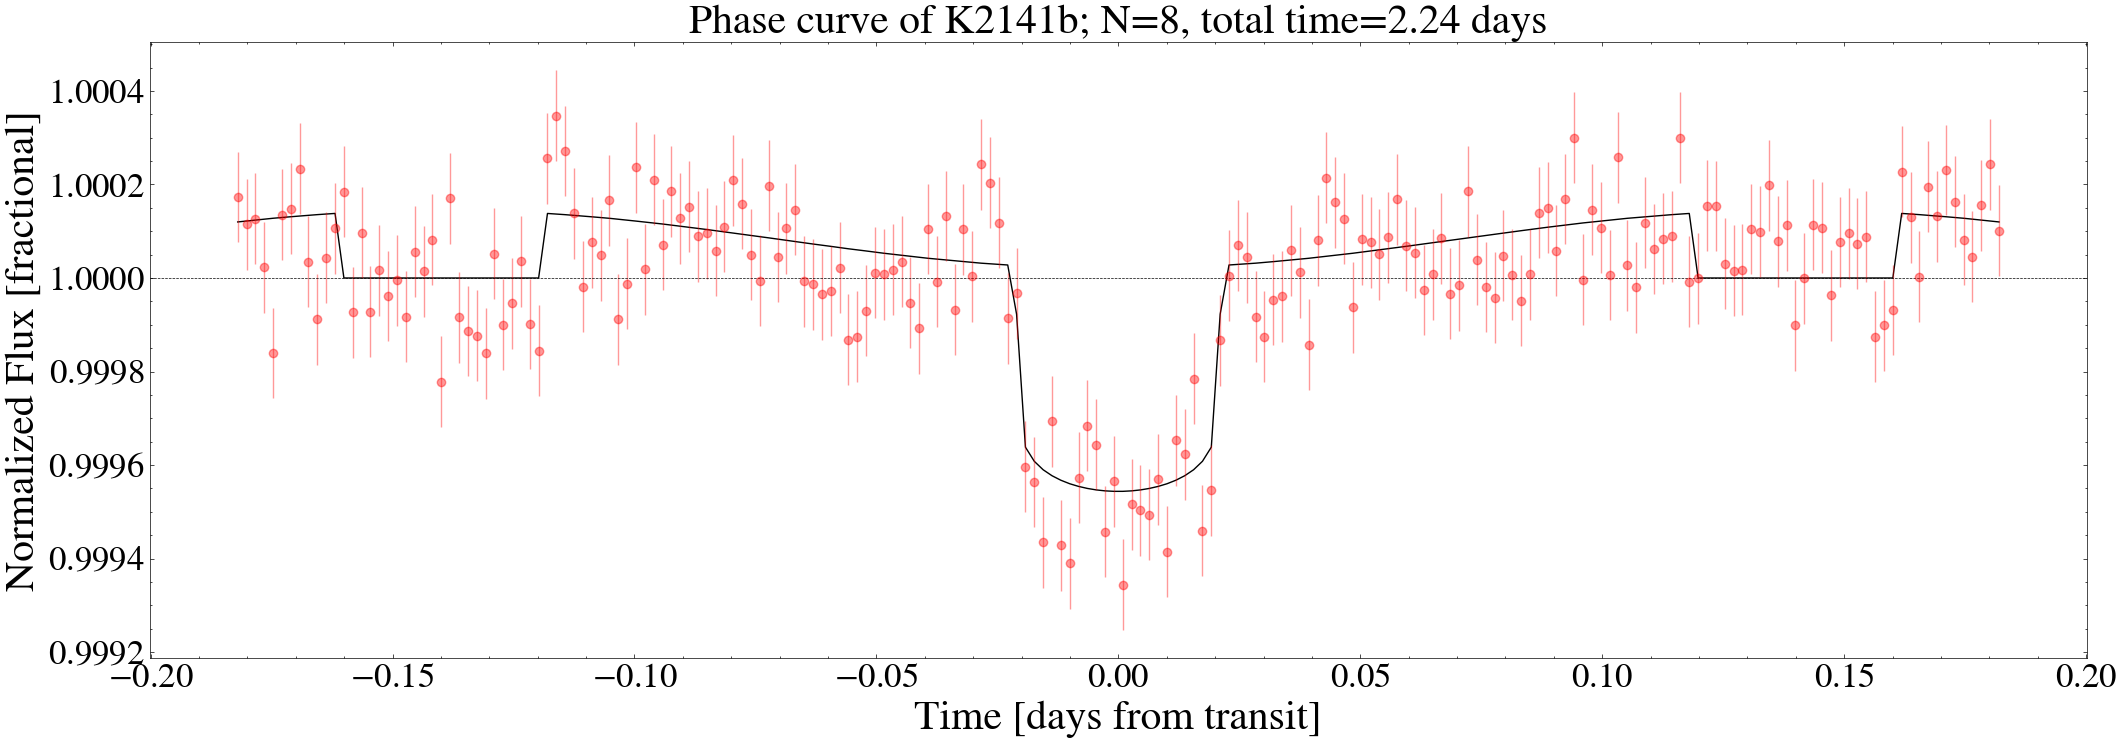

In [61]:
plt.figure(figsize=(25, 8))
hs._orbitals_hours = hs._orbitals * 24
plt.plot(hs._orbitals, binned_flux, color='black', label=f'')
#plt.plot((hs._orbitals, hs._orbitals), (rand - binned_err, rand + binned_err), '-', color='red', alpha=0.5

plt.errorbar(hs._orbitals, rand, yerr=binned_err, fmt='o', color='red', alpha=0.4)
plt.axhline(1, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Time [days from transit]', fontsize=30)
plt.ylabel('Normalized Flux [fractional]',fontsize=30)
plt.title(f'Phase curve of {name}b; N={N_pc}, total time={time:.2f} days',fontsize=30)
plt.ticklabel_format(useOffset=False)
plt.tick_params(axis='both', which='major', labelsize=25)
plt.legend(loc='lower right', fontsize=25)
plt.grid(False)
if name == 'K2141':
    plt.savefig(f'thesis-plots/{name}_1_phase_curve.pdf',format='pdf', bbox_inches='tight')
else:
    plt.savefig(f'thesis-plots/{name}_2_phase_curve.pdf',format='pdf', bbox_inches='tight')
plt.show()

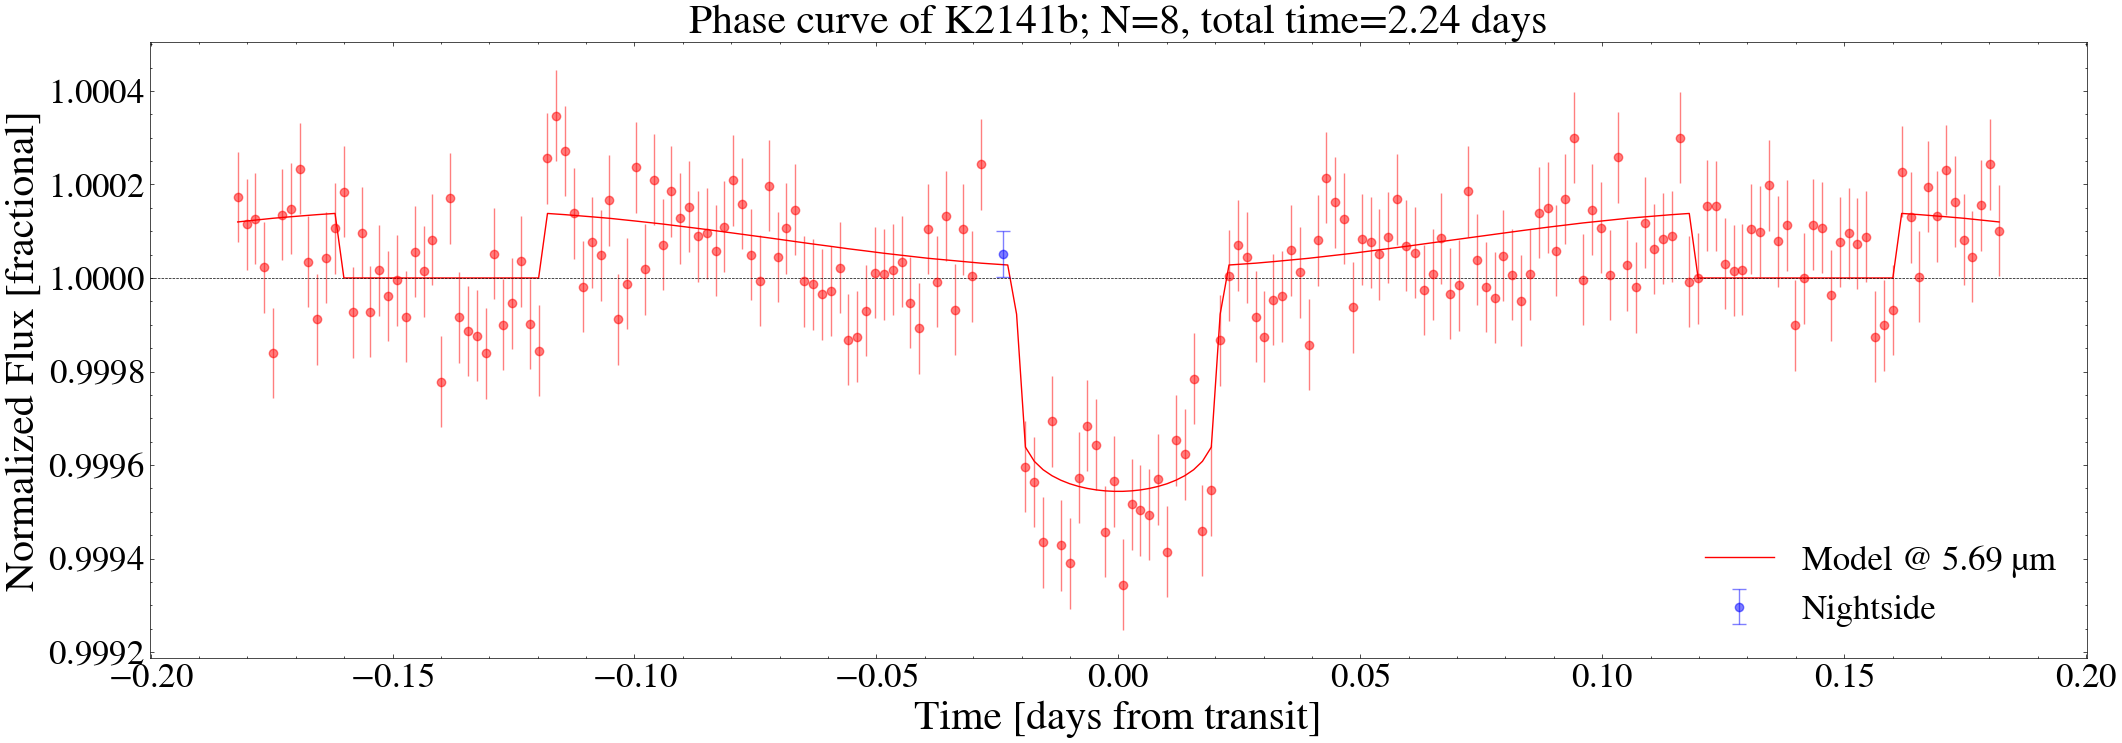

In [62]:
p1, p2, p3, p4 = binned_flux[before_ingress_idx]

v_night = ((p1 + p2) / 2 + (p3 + p4) / 2) / 2
err_l1 = binned_err / np.sqrt(2)

r1, r2, r3, r4 = rand[before_ingress_idx]
rand_night = ((r1 + r2) / 2 + (r3 + r4) / 2) / 2

err_night = binned_err / np.sqrt(4)
t_night   = np.mean(hs._orbitals[before_ingress_idx])

plt.figure(figsize=(25, 8))
plt.ticklabel_format(useOffset=False)

# Main phase curve
plt.plot(hs._orbitals, binned_flux, color='red', label=f'Model @ {binned_wl:.2f} µm')
plt.errorbar(hs._orbitals[main_idx], rand[main_idx], yerr=binned_err, fmt='o', color='red', alpha=0.5)

# Nightside binned point
plt.errorbar(t_night, rand_night, yerr=err_night, fmt='o', color='blue',
             capsize=5, label='Nightside',alpha=0.5)

plt.title(f'Phase curve of {name}b; N={N_pc}, total time={time:.2f} days',fontsize=30)
plt.axhline(1, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Time [days from transit]',fontsize=30)
plt.ylabel('Normalized Flux [fractional]',fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=25)
plt.legend(loc='lower right',fontsize=25)
plt.grid(False)
if name == 'K2141' or name == 'TOI431':
    plt.savefig(f'thesis-plots/{name}_1_binned_phase_curve.pdf',format='pdf', bbox_inches='tight')
else:
    plt.savefig(f'thesis-plots/{name}_2_binned_phase_curve.pdf',format='pdf', bbox_inches='tight')
plt.show()


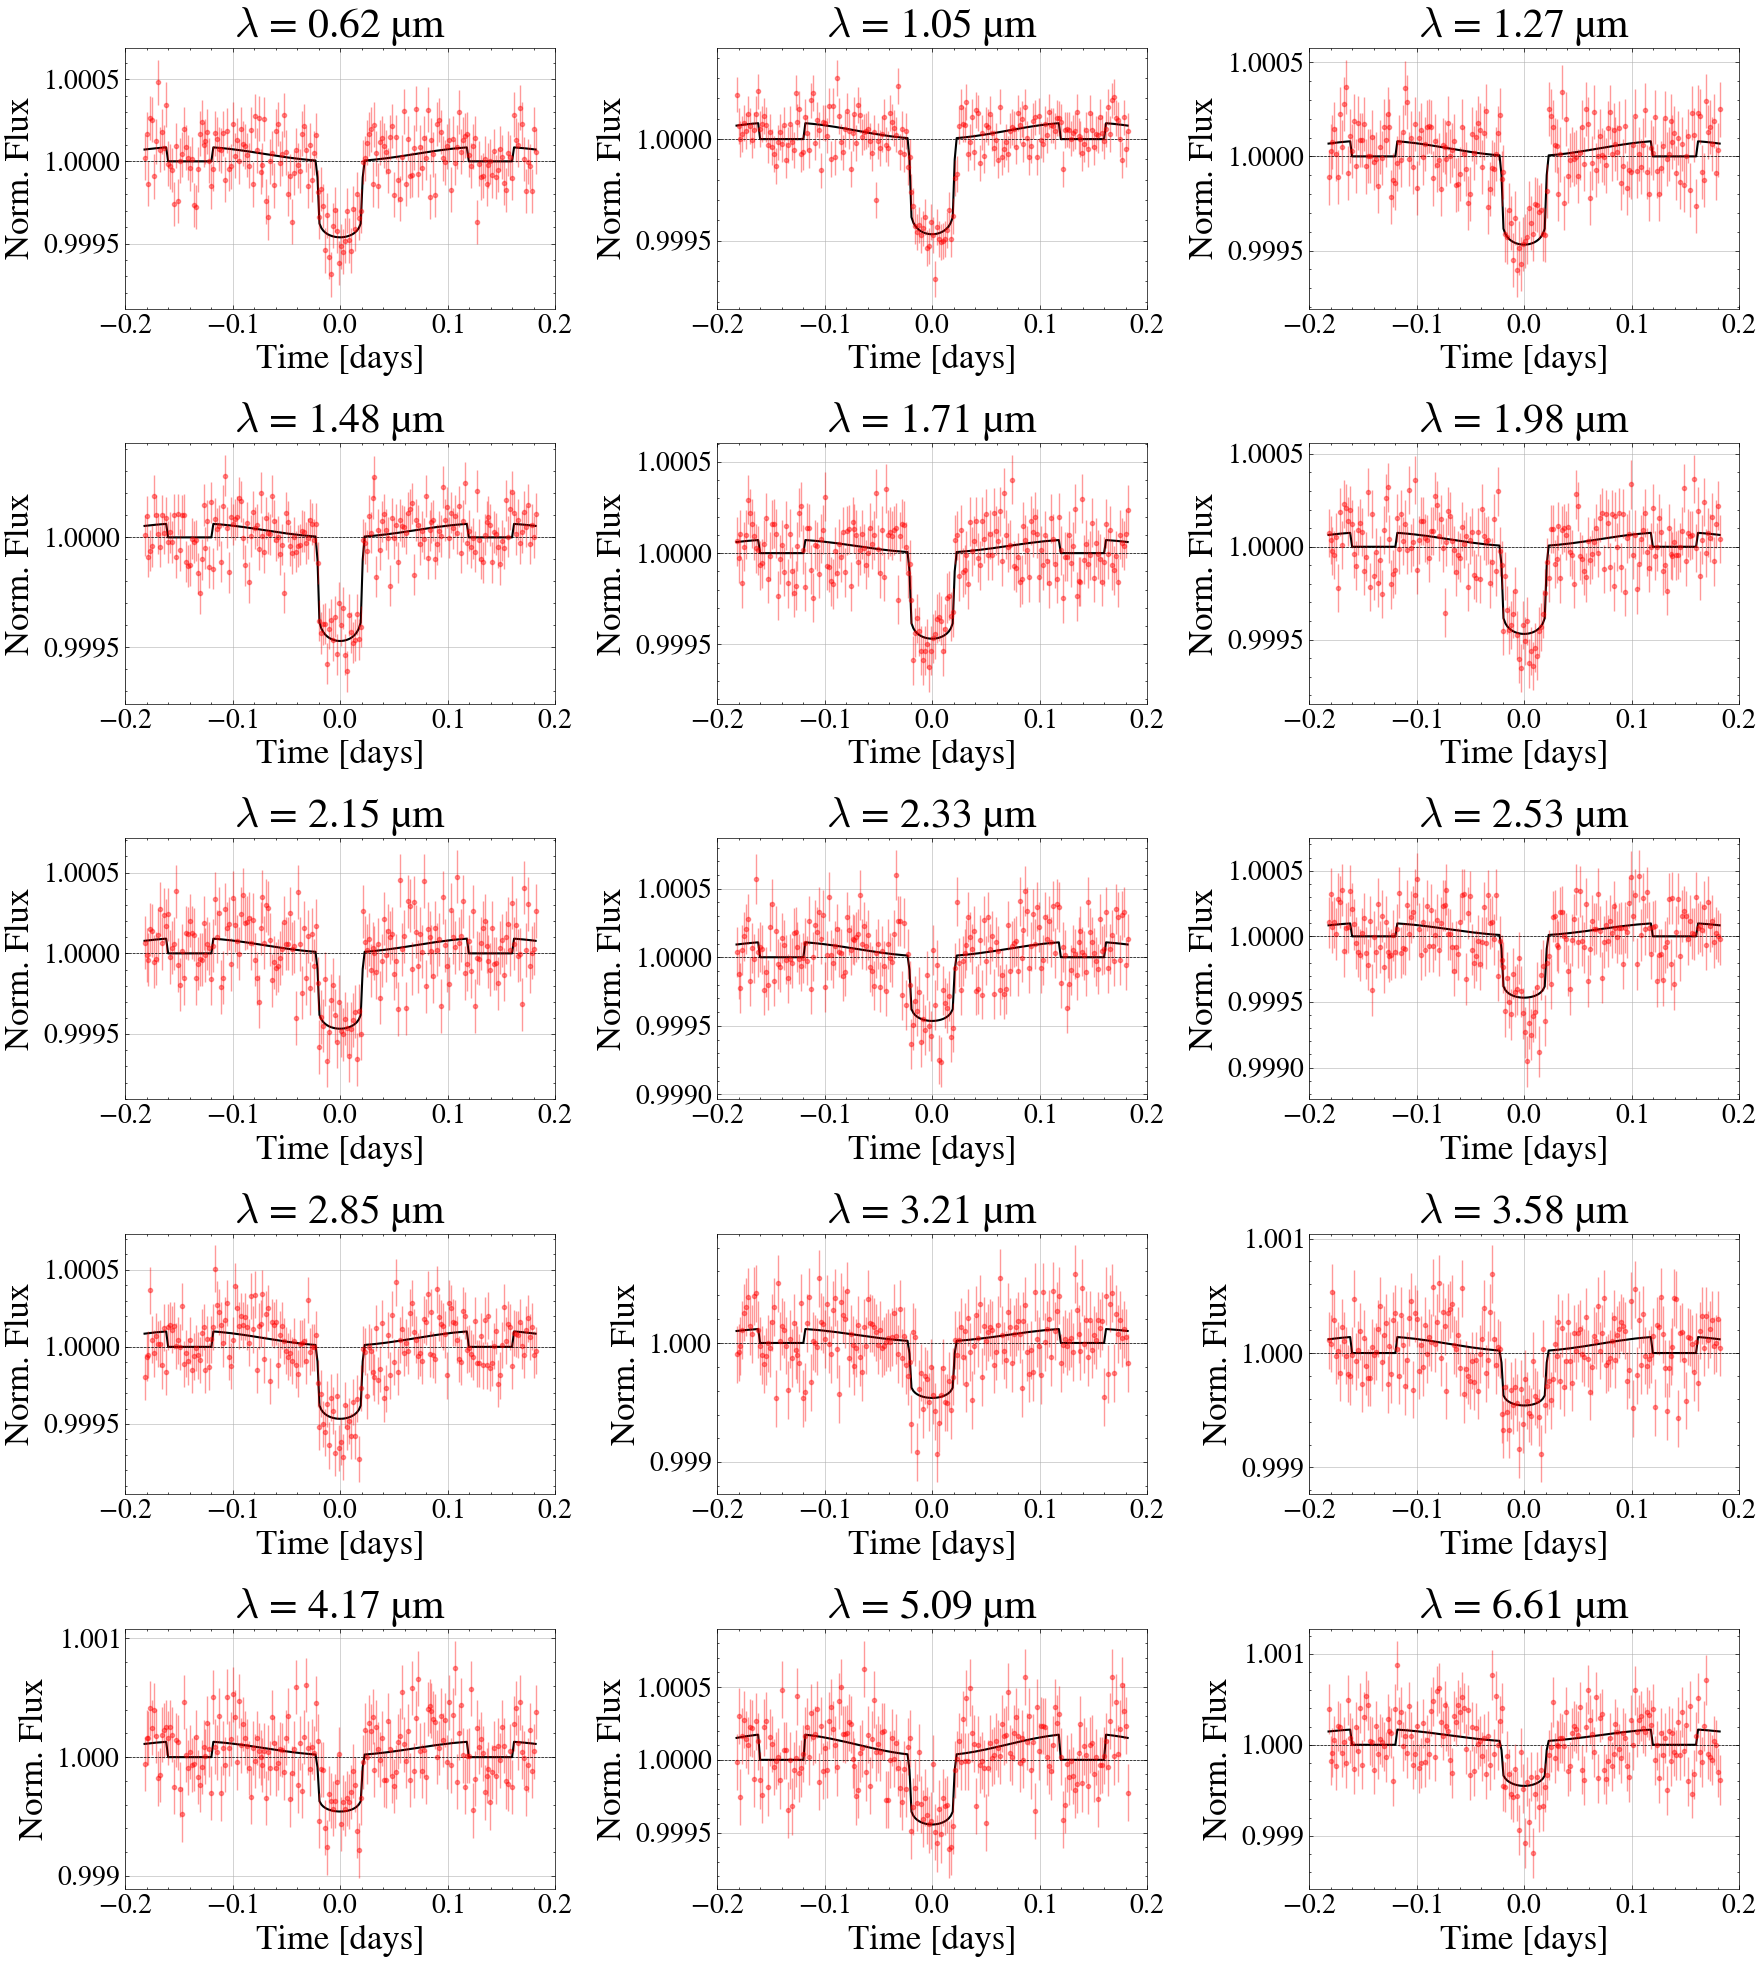

In [64]:
# ── Multi-wavelength phase curves (one per optimised spectral bin) ─────────────
import ast

# --- Load binning indices saved by spectroscopy.ipynb ---
_sim_name = f'H{H}_IW{iw}_{eff}'
_idx_csv  = f'PLANETS/{name}/{_sim_name}_S40_binning_indices.csv'
_idx_data = pd.read_csv(_idx_csv)
_bin_indices_l1 = ast.literal_eval(_idx_data['Indices_l1'].iloc[0])
_bin_indices_l2 = ast.literal_eval(_idx_data['Indices_l2'].iloc[0])
_bin_indices_l3 = ast.literal_eval(_idx_data['Indices_l3'].iloc[0])

# --- Ariel grid (kept with _ prefix to avoid collisions with cell 41) ---
_ariel       = pd.read_csv(f'./ARIEL/arielrad_{name}/tier2.csv', skiprows=6)
_wl_pc       = _ariel['Wavelength [um]'].values
_wb_pc       = _ariel['Bandwidth [um]'].values
_noise_floor = _ariel['Noise on Transit Floor [ppm]'].values * 1e-6

# Effective eclipses matching the N_pc phase-curve observation count
_dtsampled = np.mean(hs._orbitals[1:] - hs._orbitals[:-1]) * 24   # hours per sample point
_eff_ec    = N_pc * _dtsampled / T_transit_hours[planet_names.index(name)]

# -------------------------------------------------------------------
# Helper: apply the saved 3-level binning to a single flux array and
# return a sorted list of (center_wl, flux_val, flux_err) tuples.
# All three levels always bin from the original Ariel channel grid,
# exactly as bindown_multiple does internally.
# -------------------------------------------------------------------
def _apply_binning_pc(flux_i, eff_ec):
    output_i = (_wl_pc, flux_i)

    # L1 -- bin pairs of original Ariel channels
    _pts_l1  = [(_wl_pc[i], _wb_pc[i], _wl_pc[j], _wb_pc[j]) for i, j in _bin_indices_l1]
    _used_l1 = {k for pair in _bin_indices_l1 for k in pair}
    _res1    = bindown_multiple(output_i, _noise_floor, _wl_pc, flux_i, eff_ec, name, *_pts_l1)

    # Combined L1 table  ->  (center_wl, bandwidth, val, err)
    _combined = []
    for k in range(len(_wl_pc)):
        if k not in _used_l1:
            _combined.append((_wl_pc[k], _wb_pc[k], flux_i[k], _noise_floor[k] / np.sqrt(eff_ec)))
    for out in _res1:                       # out = (w1, w2, wl, val, err, bw)
        _combined.append((out[2], out[5], out[3], out[4]))
    _combined.sort(key=lambda x: x[0])

    # L2 -- bin pairs of L1 combined table entries
    _pts_l2  = [(_combined[i][0], _combined[i][1], _combined[j][0], _combined[j][1])
                for i, j in _bin_indices_l2]
    _used_l2 = {k for pair in _bin_indices_l2 for k in pair}
    _res2    = bindown_multiple(output_i, _noise_floor, _wl_pc, flux_i, eff_ec, name, *_pts_l2)

    _combined_l2 = []
    for k, keep in enumerate([i not in _used_l2 for i in range(len(_combined))]):
        if keep:
            _combined_l2.append(_combined[k])
    for out in _res2:
        _combined_l2.append((out[2], out[5], out[3], out[4]))
    _combined_l2.sort(key=lambda x: x[0])

    # L3 -- bin pairs of L2 combined table entries
    _pts_l3  = [(_combined_l2[i][0], _combined_l2[i][1], _combined_l2[j][0], _combined_l2[j][1])
                for i, j in _bin_indices_l3]
    _used_l3 = {k for pair in _bin_indices_l3 for k in pair}
    _res3    = bindown_multiple(output_i, _noise_floor, _wl_pc, flux_i, eff_ec, name, *_pts_l3)

    _final = []
    for k, keep in enumerate([i not in _used_l3 for i in range(len(_combined_l2))]):
        if keep:
            _final.append((_combined_l2[k][0], _combined_l2[k][2], _combined_l2[k][3]))
    for out in _res3:
        _final.append((out[2], out[3], out[4]))
    _final.sort(key=lambda x: x[0])
    return _final   # list of (center_wl, flux_val, flux_err)

# --- Run binning at every orbital phase ---
_final_bins_0 = _apply_binning_pc(flux[0, :], _eff_ec)
_n_bins       = len(_final_bins_0)
_bin_wls      = np.array([b[0] for b in _final_bins_0])

_binned_flux_all = np.zeros((len(hs._orbitals), _n_bins))
_binned_err_all  = np.zeros((len(hs._orbitals), _n_bins))

for _i_orb in range(len(hs._orbitals)):
    _bins_i = _apply_binning_pc(flux[_i_orb, :], _eff_ec)
    for _b, (_wl_b, _val_b, _err_b) in enumerate(_bins_i):
        _binned_flux_all[_i_orb, _b] = _val_b
        _binned_err_all[_i_orb, _b]  = _err_b

# Errors are phase-independent (instrument noise); take from the first phase
_binned_err_pc = _binned_err_all[0, :]

# --- Plot: one subplot per wavelength bin ---
_ncols = 3
_nrows = int(np.ceil(_n_bins / _ncols))
fig_mwl, _axes = plt.subplots(_nrows, _ncols, figsize=(6 * _ncols, 4 * _nrows), sharey=False)
_axes = np.array(_axes).flatten()

for _b in range(_n_bins):
    _ax      = _axes[_b]
    _model_b = _binned_flux_all[:, _b]
    _err_b   = _binned_err_pc[_b]
    _rand_b  = np.random.normal(_model_b, _err_b)

    _ax.plot(hs._orbitals, _model_b, color='black', lw=1.5)
    _ax.errorbar(hs._orbitals, _rand_b, yerr=_err_b,
                 fmt='o', color='red', alpha=0.4, markersize=3)
    _ax.axhline(1, color='black', linestyle='--', linewidth=0.5)
    _ax.set_title(rf'$\lambda$ = {_bin_wls[_b]:.2f} µm', fontsize=30)
    _ax.set_xlabel('Time [days]', fontsize=25)
    _ax.set_ylabel('Norm. Flux', fontsize=25)
    _ax.ticklabel_format(useOffset=False)

for _b in range(_n_bins, len(_axes)):
    _axes[_b].set_visible(False)

#fig_mwl.suptitle(
#    f'Phase curves of {name}b at each optimised spectral bin \n'
#    f'N={N_pc}, total time={time:.2f} days',
#    fontsize=25, y=1.01)
plt.tight_layout()
savefig(f'thesis-plots/{name}_multiwavelength_phase_curves.pdf', format='pdf', bbox_inches='tight')
plt.show()


# Day-Night contrast in fractional day-night flux variation 

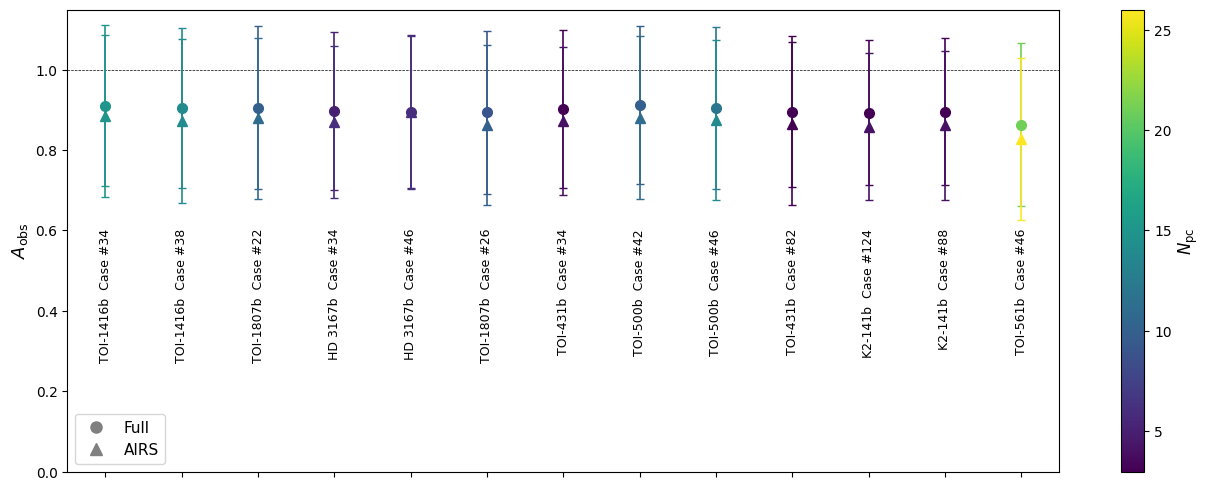

In [21]:
#extract full dataframe from supertable_code.py
exec(open("supertable_code.py").read())

# obs still has A_obs/N_pc columns (df dropped them in col_order); filter LHS 1478b
obs_plot = obs[~obs["Planet"].str.contains("LHS 1478b")].dropna(subset=["A_obs"]).copy()
obs_plot = obs_plot.sort_values("T_day [K]").reset_index(drop=True)

labels = [f"{row['Planet']}  Case #{int(row['Case #'])}" for _, row in obs_plot.iterrows()]
x = np.arange(len(obs_plot))

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

all_npc = pd.concat([obs_plot["N_pc"], obs_plot["N_pc_AIRS"]]).dropna()
norm = Normalize(vmin=all_npc.min(), vmax=all_npc.max())
cmap = plt.get_cmap("viridis")

fig = figure(figsize=(16, 6))
frame = fig.add_subplot(1, 1, 1)

for i, row in obs_plot.iterrows():
    if not np.isnan(row["A_obs"]):
        c = cmap(norm(row["N_pc"]))
        frame.errorbar(i, row["A_obs"], yerr=row["\u03c3_obs"],
                       fmt='o', color=c, markersize=7, capsize=3, elinewidth=1.2, zorder=3)
    if not np.isnan(row["A_obs_AIRS"]):
        c = cmap(norm(row["N_pc_AIRS"]))
        frame.errorbar(i, row["A_obs_AIRS"], yerr=row["\u03c3_obs_AIRS"],
                       fmt='^', color=c, markersize=7, capsize=3, elinewidth=1.2, zorder=3)

# vertical case labels in data coordinates, just below the lowest error bar bottom
y_bottom = min(
    (obs_plot["A_obs"] - obs_plot["\u03c3_obs"]).min(),
    (obs_plot["A_obs_AIRS"] - obs_plot["\u03c3_obs_AIRS"]).min()
)
frame.set_xticks(x)
frame.set_xticklabels([])
for i, label in enumerate(labels):
    frame.text(i, y_bottom - 0.02, label, rotation=90, ha='center', va='top', fontsize=9)

frame.set_ylabel(r"$A_{\rm obs}$", fontsize=13)
frame.set_xlim(-0.5, len(obs_plot) - 0.5)
frame.axhline(1, color='black', linestyle='--', linewidth=0.5)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=frame)
cbar.set_label(r"$N_{\rm pc}$", fontsize=12)

frame.legend(handles=[
    Line2D([0], [0], marker='o', color='gray', label='Full', linestyle='None', markersize=8),
    Line2D([0], [0], marker='^', color='gray', label='AIRS', linestyle='None', markersize=8),
], fontsize=11)

plt.ylim(0, 1.15)
savefig('thesis-plots/A_obs_scatter.pdf', bbox_inches='tight')
plt.show()
